Runs analysis with rare codon patches, relative to within-genes and between-genes controls, for analysis of 

-- Riboseq data  
-- RBP binding  
-- GTEx  
-- repeats  
-- secondary structure  

In [1]:

import pyBigWig
import pandas as pd
import numpy as np
import os
import seaborn as sns
import matplotlib.pyplot as plt
import random
import pybedtools
import math
from scipy.stats import zscore, fisher_exact, spearmanr, ttest_rel, ttest_ind
import gzip
import ast
import statsmodels.api as sm
import statsmodels.formula.api as smf
import yaml
from pathlib import Path
import pandas as pd
import pyBigWig
import os
import glob



In [2]:
## to supress warnings
import warnings
warnings.filterwarnings('ignore')

# Ribo-seq analysis

In [3]:

# cd to repo
os.chdir('/Users/jacobfine/Library/CloudStorage/OneDrive-Personal/U of T 2022-2023/Blencowe/Jan_2024_Blencowe/NOV_2024_reanalysis/sequence_analysis_may_2026/compare_backgrounds_codon')
print(f"working directory: {os.getcwd()}")

# loads config
config_path = Path('configs/read_files/read_files.yaml')
with open(config_path, 'r') as f:
    config = yaml.safe_load(f)

loading_cfg = config['loading_config']


# loads ribo-seq bigwig files, and matched rna-seq
print("loading ribo-seq bigwig files:")
ribo_path = Path(config['input_files']['riboseq']['ribo_coverage']['path'])
rna_path = Path(config['input_files']['riboseq']['mrna_coverage']['path'])

ribo_wig = None
rna_wig = None

if ribo_path.exists():
    ribo_wig = pyBigWig.open(str(ribo_path))
    print(f"  loaded ribo_coverage: {ribo_path}")
else:
    print(f"  File not found: {ribo_path}")

if rna_path.exists():
    rna_wig = pyBigWig.open(str(rna_path))
    print(f"  loaded mrna_coverage: {rna_path}")
else:
    print(f"  File not found: {rna_path}")



working directory: /Users/jacobfine/Library/CloudStorage/OneDrive-Personal/U of T 2022-2023/Blencowe/Jan_2024_Blencowe/NOV_2024_reanalysis/sequence_analysis_may_2026/compare_backgrounds_codon
loading ribo-seq bigwig files:
  loaded ribo_coverage: input_files/riboseq/Haas20_All.RiboCov.bw
  loaded mrna_coverage: input_files/riboseq/Haas20_All.mRNACov.bw


In [4]:

# loads required files for this

import yaml
from pathlib import Path
import pandas as pd

class ConfigLoader:
    
    def __init__(self, config_path='read_files.yaml'):
        with open(config_path, 'r') as f:
            self.config = yaml.safe_load(f)
    
    def load_csv(self, category, key):
        # function to load csv from configs
        file_info = self.config['input_files'][category][key]
        path = Path(file_info['path'])
        csv_config = self.config['loading_config']['csv']
        
        df = pd.read_csv(path, **csv_config)
        print(f"loaded {key}: {df.shape}")
        return df
    
    def load_bed(self, category, key):
        # function to load bed file from configs
        file_info = self.config['input_files'][category][key]
        path = Path(file_info['path'])
        bed_config = self.config['loading_config']['bed']
        
        df = pd.read_csv(path, **bed_config)
        print(f"loaded {key}: {df.shape}")
        return df

loader = ConfigLoader('configs/read_files/read_files.yaml')

# loads files based on config
longest_orfs_df = loader.load_csv('seq_process', 'longest_orfs')
# longest_orfs_df_expanded = loader.load_csv('seq_process', 'longest_orfs_expanded')
# df_master = loader.load_csv('kmers', 'gene_master')


loaded longest_orfs: (20202, 6)


In [5]:
import os
from pathlib import Path

# loads bed files from output directory
bed_dir = Path('outputs/files/output_kmers/')

bed_dict = {}

# reads the bed files in the directory
for filename in os.listdir(bed_dir):
    if filename.endswith(".bed"):
        filepath = os.path.join(bed_dir, filename)
        kmer_set_name = filename.replace(".bed", "")
        
        
        # converts bed files into df
        df = pd.read_csv(filepath, sep='\t', header=None,
                         names=["chrom", "start", "end", "name", "score", "strand"])
        df["name"] = df["name"] + "---" + kmer_set_name  # indicates where it came from
        bed_dict[kmer_set_name] = df
        print(f"loaded {kmer_set_name}: {df.shape}")

# combines k-mer sets into a single df
combined_df_kmers = pd.concat(bed_dict.values(), ignore_index=True)

# gives a unique identifier for each k-mer
combined_df_kmers['genomic_id'] = (
    combined_df_kmers['chrom'].astype(str) + ":" + 
    combined_df_kmers['start'].astype(str) + "-" + 
    combined_df_kmers['end'].astype(str) + "---" + 
    combined_df_kmers['name'].astype(str)
)

print(f"combined dataframe: {combined_df_kmers.shape}")
print(f"k-mer sets loaded: {list(bed_dict.keys())}")


loaded within_genes: (571, 6)
loaded between_genes: (1508, 6)
loaded rare_patches: (482, 6)
combined dataframe: (2561, 7)
k-mer sets loaded: ['within_genes', 'between_genes', 'rare_patches']


In [6]:
import yaml
from pathlib import Path
import pandas as pd

# load config
config_path = Path('configs/read_files/read_files.yaml')
with open(config_path, 'r') as f:
    config = yaml.safe_load(f)

loading_cfg = config['loading_config']

# load longest ORF information
df_longest_orf = pd.read_csv(
    config['input_files']['seq_process']['longest_orfs']['path'],
    **loading_cfg['csv']
)
all_coding_genes = list(set(df_longest_orf['name']))

print(f"Loaded longest ORFs: {df_longest_orf.shape}")
print(f"Total coding genes: {len(all_coding_genes)}")

# load gene coordinates
df_gene_coords = pd.read_csv(
    config['input_files']['seq_process']['coordinates']['path'],
    **loading_cfg['csv']
)

print(f"loaded gene coordinates: {df_gene_coords.shape}")

# Extract host gene and k-mer set, handling both naming schemes
# Background k-mers: ENSG00000168264__s0__from__ENSG00000004142_(117, 168)---within_genes
# Rare patches: ENSG00000240445_(102_156)_p2---rare_patches

def extract_host_gene(name):
    if '---rare_patches' in name:
        # Rare patches: extract ENSG before the underscore and coordinates
        return name.split('_(')[0]  
    else:
        # Background: extract first part before __
        return name.split('__')[0]

def extract_kmer_set(name):
    if '---rare_patches' in name:
        return 'rare_patches'
    else:
        return name.split('---')[-1]

combined_df_kmers['host_gene'] = combined_df_kmers['name'].apply(extract_host_gene)
combined_df_kmers['kmer_set'] = combined_df_kmers['name'].apply(extract_kmer_set)

print(f"\nK-mer sets found: {combined_df_kmers['kmer_set'].unique()}")
print(f"Total k-mers: {len(combined_df_kmers)}")

# create all_kmer_info dataframe
all_kmer_info = combined_df_kmers[['name', 'host_gene', 'kmer_set', 'chrom', 'start', 'end', 'strand']].copy()


Loaded longest ORFs: (20202, 6)
Total coding genes: 20202
loaded gene coordinates: (62702, 7)

K-mer sets found: ['within_genes' 'between_genes' 'rare_patches']
Total k-mers: 2561


In [7]:
# a function that given some genomic coordiantes, gets the riboseq counts (or rnaseq counts) at that position
def get_riboseq_counts_at_position(chrom, start, end, bwfile):

    # ensures coords make sense
    if start > end:
        return float('nan')  

    try:
        # queries bed object to get values for region
        score_values = bwfile.values(chrom, start, end)
        
        # filters to keep float values that are not nan
        score_values = [x for x in score_values if isinstance(x, float) and not math.isnan(x)]

        # if no valid values, return nan
        if not score_values:
            return float('nan')

        # print the sum of the values in the region
        total_values_in_region = sum(score_values)

        return total_values_in_region
    # in cases where the above isn't satisfied
    except Exception as e:
        return float('nan')  # returns NaN for this

In [8]:
# load master dataframe
df_master = pd.read_csv(config['input_files']['kmers']['gene_master']['path'], **loading_cfg['csv'])
print(f"Loaded df_master: {df_master.shape}")

Loaded df_master: (482, 390)


In [9]:
import pandas as pd

# applies the riboseq counts to some position; given a list of k-mers, can get the riboseq counts there per nt; updates df accordingly

def apply_riboseq_counts(df, bwfile, chrom_col='chrom', start_col='start_1', end_col='end_1',out_col ='outcol'):

    # a function we can apply to each row
    def apply_to_row(row):
        chrom = row[chrom_col]
        start = row[start_col]
        end = row[end_col]
        return get_riboseq_counts_at_position(chrom, start, end, bwfile)
    
    df[out_col] = df.apply(apply_to_row, axis=1)
    df[f'{out_col}_per_nt'] = round(df[out_col]/(df[end_col]-df[start_col]),5)  # relative counts per nt
    
    return df

In [10]:
# do it for RNA and ribo

df = all_kmer_info.copy()

df = apply_riboseq_counts(df, rna_wig, chrom_col='chrom', start_col='start', end_col='end',out_col='native_mRNA_counts_in_kmer')
df = apply_riboseq_counts(df, ribo_wig, chrom_col='chrom', start_col='start', end_col='end',out_col='native_ribo_counts_in_kmer')

rcegs = list(set(df_master['ensg_name_x']))
len(rcegs)


# to lookup coords of longest orfs, and cds for rcegs
lookup_cds = dict(zip(df_longest_orf['name'],df_longest_orf['coordinates']))
lookup_cds_rcegs = {key: value for key, value in lookup_cds.items() if key in rcegs}
    
# now, to get average counts per nt accross the entire orf (before was just kmers)

def compute_orf_counts_per_nt(
    lookup_cds_dict,
    wig,
    gene_list=None,
    verbose=False
):

    # dict to store av counts per nt accross orf
    av_value_gene_dict = {}
    gene_keys = gene_list if gene_list else lookup_cds_dict.keys()

    # iterates through eacch gene
    for gene in gene_keys:
        # gets the coord list for that ORF
        coords_list = ast.literal_eval(lookup_cds_dict[gene])
        sum_counts_ORF = 0.0
        length_ORF = 0
        # prints gene name
        if verbose:
            print(gene)
        # goes through each coord in the ORF coords and gets occupancy there
        for coord in coords_list:
            chrom, start, end = coord[0], coord[1], coord[2]
            length_region = end - start
            # keeps track of ORF length 
            length_ORF += length_region
            # sum of counts in region from previopus function (treats the ORF slice as a kmer)
            sum_counts_region = get_riboseq_counts_at_position(chrom, start, end, wig)
            if not isinstance(sum_counts_region, float) or math.isnan(sum_counts_region):
                sum_counts_region = 0.0 

            # updates the sum of count accross the ORF
            sum_counts_ORF += sum_counts_region

        # avereage density accross ORF
        counts_per_nt = round(sum_counts_ORF / length_ORF, 4) if length_ORF > 0 else float('nan')
        av_value_gene_dict[gene] = counts_per_nt
        # prints the counts mapping to ORF, then counts per nt
        if verbose:
            print(f"  total counts: {sum_counts_ORF}, length: {length_ORF}, avg: {counts_per_nt}")

    return av_value_gene_dict

In [11]:
# to lookup coords of longest orfs, and cds for rcegs
lookup_cds = dict(zip(df_longest_orf['name'],df_longest_orf['coordinates']))
lookup_cds_rcegs = {key: value for key, value in lookup_cds.items() if key in rcegs}
    
# now, to get average counts per nt accross the entire orf (before was just kmers)

def compute_orf_counts_per_nt(
    lookup_cds_dict,
    wig,
    gene_list=None,
    verbose=False
):

    # dict to store av counts per nt accross orf
    av_value_gene_dict = {}
    gene_keys = gene_list if gene_list else lookup_cds_dict.keys()

    # iterates through eacch gene
    for gene in gene_keys:
        # gets the coord list for that ORF
        coords_list = ast.literal_eval(lookup_cds_dict[gene])
        sum_counts_ORF = 0.0
        length_ORF = 0
        # prints gene name
        if verbose:
            print(gene)
        # goes through each coord in the ORF coords and gets occupancy there
        for coord in coords_list:
            chrom, start, end = coord[0], coord[1], coord[2]
            length_region = end - start
            # keeps track of ORF length 
            length_ORF += length_region
            # sum of counts in region from previopus function (treats the ORF slice as a kmer)
            sum_counts_region = get_riboseq_counts_at_position(chrom, start, end, wig)
            if not isinstance(sum_counts_region, float) or math.isnan(sum_counts_region):
                sum_counts_region = 0.0 

            # updates the sum of count accross the ORF
            sum_counts_ORF += sum_counts_region

        # avereage density accross ORF
        counts_per_nt = round(sum_counts_ORF / length_ORF, 4) if length_ORF > 0 else float('nan')
        av_value_gene_dict[gene] = counts_per_nt
        # prints the counts mapping to ORF, then counts per nt
        if verbose:
            print(f"  total counts: {sum_counts_ORF}, length: {length_ORF}, avg: {counts_per_nt}")

    return av_value_gene_dict
# calls it for ribo
ribo_avg_dict = compute_orf_counts_per_nt(
    lookup_cds_dict=lookup_cds,
    wig=ribo_wig,
    verbose=False
)

df['ORF_ribo_counts_per_nt'] = df['host_gene'].map(ribo_avg_dict)
# calls it for RNA
rna_avg_dict = compute_orf_counts_per_nt(
    lookup_cds_dict=lookup_cds,
    wig=rna_wig,
    verbose=False
)

df['ORF_rna_counts_per_nt'] = df['host_gene'].map(rna_avg_dict)

df['length'] = df['end']-df['start'] ## gets length of region

df['meta_kmer_id_if_rare']=df['name'].str.split('---').str[0]
map_score_30_mers = dict(zip(df_master['meta_kmer_id'],df_master['map_mean_K30_in_kmer_per_nt']))
oe_score = dict(zip(df_master['meta_kmer_id'],df_master['ratio_pct_obs_exp']))

# includes the mappability scores and oe_scores
df['map_score_30_mers'] = df['meta_kmer_id_if_rare'].map(map_score_30_mers)
df['oe_score'] = df['meta_kmer_id_if_rare'].map(oe_score)


# makes a 'design matrix' to operate with; added 'name'
df_design = df[['kmer_set','host_gene','name','native_mRNA_counts_in_kmer_per_nt','native_ribo_counts_in_kmer_per_nt','ORF_ribo_counts_per_nt','ORF_rna_counts_per_nt','length','map_score_30_mers','oe_score']]
# indicator function of whether the k-mer is a rare codon patch or not
df_design['is_rare'] = (df_design['kmer_set'] == 'rare_patches').astype(int)


In [12]:
df_design_subset = df_design.copy()
# log ratios for local relatie to global ribosome occ and RNA reads
df_design['log_ribo_ratio'] = np.log2((df_design['native_ribo_counts_in_kmer_per_nt'] + 1e-3) / 
                                       (df_design['ORF_ribo_counts_per_nt'] + 1e-3))

df_design['log_rna_ratio'] = np.log2((df_design['native_mRNA_counts_in_kmer_per_nt'] + 1e-3) /
                                      (df_design['ORF_rna_counts_per_nt'] + 1e-3))
df_design_subset = df_design.dropna(subset=['log_rna_ratio', 'log_ribo_ratio'])

# sets up quantile regression; first, regresses ribo on RNA 
model_qr_rna = smf.quantreg("log_ribo_ratio ~ log_rna_ratio", df_design_subset)
result_rna = model_qr_rna.fit(q=0.5)

# then stores residuals from that regression
df_design_subset["rna_adjusted_ribo"] = df_design_subset["log_ribo_ratio"] - result_rna.predict(df_design_subset)

# now, regresses residuals on whether the k-mer is rare or not
model_resid = smf.quantreg("rna_adjusted_ribo ~ is_rare", df_design_subset)
result_resid = model_resid.fit(q=0.5)
result_resid.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                         QuantReg Regression Results                          
==============================================================================
Dep. Variable:      rna_adjusted_ribo   Pseudo R-squared:             0.006446
Model:                       QuantReg   Bandwidth:                      0.5179
Method:                 Least Squares   Sparsity:                        2.956
Date:                Wed, 26 Aug 2026   No. Observations:                 1404
Time:                        14:28:09   Df Residuals:                     1402
                                        Df Model:                            1
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.0448      0.044      1.025      0.306      -0.041       0.131
is_rare       -0.3811      0.101     -3.758      0.000      -0.580      -0.182
==============================================================================
"""

In [13]:
%load_ext rpy2.ipython

In [14]:
import pandas as pd
import statsmodels.formula.api as smf
from statsmodels.robust.norms import HuberT
from statsmodels.stats.multitest import multipletests


## runs various regressions to correct for RNA level and determine if rare codon patches are predictive of occupancy
## optional; filter by mappabiolity first
# df_design_subset_high_map  = df_design_subset[df_design_subset['map_score_30_mers']>0.95]
# df_design_subset_high_map = df_design_subset.copy()


# df_i = df_design_subset_high_map.copy()


df_i = df_design_subset.copy()
coef_list = []

# median quantile regression
model_qr = smf.quantreg("log_ribo_ratio ~ log_rna_ratio + is_rare", data=df_i)
results_qr = model_qr.fit(q=0.5)

for term in results_qr.params.index:
    if term != "Intercept":
        ci_low, ci_high = results_qr.conf_int().loc[term]
        ## saves results
        coef_list.append({
            "method": "QR_0.5",
            "quantile": 0.5,
            "term": term,
            "coef": results_qr.params[term],
            "se": results_qr.bse[term],
            "pval": results_qr.pvalues[term],
            "ci_low": ci_low,
            "ci_high": ci_high
        })
pd.DataFrame(coef_list)

,method,quantile,term,coef,se,pval,ci_low,ci_high
0,QR_0.5,0.5,log_rna_ratio,0.144923,0.015593,5.510270e-20,0.114334,0.175512
1,QR_0.5,0.5,is_rare,-0.407773,0.102297,7.061166e-05,-0.608445,-0.207101


In [43]:
## stats test comparing ribosome occupancy at rare codon patches versus backgrounds
from scipy.stats import ttest_ind
import numpy as np

def cohen_d(group1, group2):
    n1, n2 = len(group1), len(group2)
    s1, s2 = np.var(group1, ddof=1), np.var(group2, ddof=1)
    pooled_std = np.sqrt(((n1 - 1)*s1 + (n2 - 1)*s2) / (n1 + n2 - 2))
    return (np.mean(group1) - np.mean(group2)) / pooled_std


rare_before = df_design_subset[df_design_subset['kmer_set'] == 'rare_patches']['rna_adjusted_ribo']
within_before = df_design_subset[df_design_subset['kmer_set'] == 'within_genes']['rna_adjusted_ribo']
between_before = df_design_subset[df_design_subset['kmer_set'] == 'between_genes']['rna_adjusted_ribo']

rare_mean_before = rare_before.mean()
within_mean_before = within_before.mean()
between_mean_before = between_before.mean()

# fold change and percent difference
fc_within_before = rare_mean_before / within_mean_before
fc_between_before = rare_mean_before / between_mean_before
pct_within_before = 100 * (rare_mean_before - within_mean_before) / within_mean_before
pct_between_before = 100 * (rare_mean_before - between_mean_before) / between_mean_before

d_within_before = cohen_d(rare_before, within_before)
d_between_before = cohen_d(rare_before, between_before)

p_within_before = ttest_ind(rare_before, within_before, equal_var=False).pvalue
p_between_before = ttest_ind(rare_before, between_before, equal_var=False).pvalue
# filter rare codon patches to cases that are above 0.95
df_design_subset_high_map = df_design_subset[
    (df_design_subset['kmer_set'] != 'rare_patches') | 
    (df_design_subset['map_score_30_mers'] > 0.95)
]

df_design_subset_high_map
rare_after = df_design_subset_high_map[df_design_subset_high_map['kmer_set'] == 'rare_patches']['rna_adjusted_ribo']
within_after = df_design_subset_high_map[df_design_subset_high_map['kmer_set'] == 'within_genes']['rna_adjusted_ribo']
between_after = df_design_subset_high_map[df_design_subset_high_map['kmer_set'] == 'between_genes']['rna_adjusted_ribo']

rare_mean_after = rare_after.mean()
within_mean_after = within_after.mean()
between_mean_after = between_after.mean()

fc_within_after = rare_mean_after / within_mean_after
fc_between_after = rare_mean_after / between_mean_after
pct_within_after = 100 * (rare_mean_after - within_mean_after) / within_mean_after
pct_between_after = 100 * (rare_mean_after - between_mean_after) / between_mean_after

d_within_after = cohen_d(rare_after, within_after)
d_between_after = cohen_d(rare_after, between_after)

p_within_after = ttest_ind(rare_after, within_after, equal_var=False).pvalue
p_between_after = ttest_ind(rare_after, between_after, equal_var=False).pvalue

# prints results

print(f"Before filtering (all data):")
print(f"  Rare vs Within: FC = {fc_within_before:.3f}-fold, {pct_within_before:.2f}%, d = {d_within_before:.3f}, p = {p_within_before:.3e}")
print(f"  Rare vs Between: FC = {fc_between_before:.3f}-fold, {pct_between_before:.2f}%, d = {d_between_before:.3f}, p = {p_between_before:.3e}")

print(f"\nAfter filtering (high map score > 0.95):")
print(f"  Rare vs Within: FC = {fc_within_after:.3f}-fold, {pct_within_after:.2f}%, d = {d_within_after:.3f}, p = {p_within_after:.3e}")
print(f"  Rare vs Between: FC = {fc_between_after:.3f}-fold, {pct_between_after:.2f}%, d = {d_between_after:.3f}, p = {p_between_after:.3e}")

Before filtering (all data):
  Rare vs Within: FC = 2.995-fold, 199.48%, d = -0.174, p = 4.129e-02
  Rare vs Between: FC = 3.257-fold, 225.74%, d = -0.163, p = 2.431e-02

After filtering (high map score > 0.95):
  Rare vs Within: FC = 3.131-fold, 213.08%, d = -0.189, p = 3.117e-02
  Rare vs Between: FC = 3.405-fold, 240.54%, d = -0.175, p = 1.785e-02


[1] "Summary statistics:"
# A tibble: 3 × 5
  group           mean  median    sd     n
  <fct>          <dbl>   <dbl> <dbl> <int>
1 between_genes -0.107  0.0316  1.47   809
2 within_genes  -0.117  0.0627  1.18   334
3 rare_patches  -0.349 -0.336   1.51   261
[1] "\nt-test results:"
                     comparison statistic    p_value  mean_rare mean_control
1  rare_patches vs within_genes -2.046134 0.04128766 -0.3493607   -0.1166564
2 rare_patches vs between_genes -2.260168 0.02430983 -0.3493607   -0.1072522



Attaching package: ‘dplyr’

The following objects are masked from ‘package:stats’:

    filter, lag

The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union

In addition: Warning messages:
1: package ‘dplyr’ was built under R version 4.5.3 
2: package ‘ggplot2’ was built under R version 4.5.3 
3: In geom_signif(comparisons = list(c("rare_patches", "within_genes"),  :
  Ignoring unknown parameters: `method`


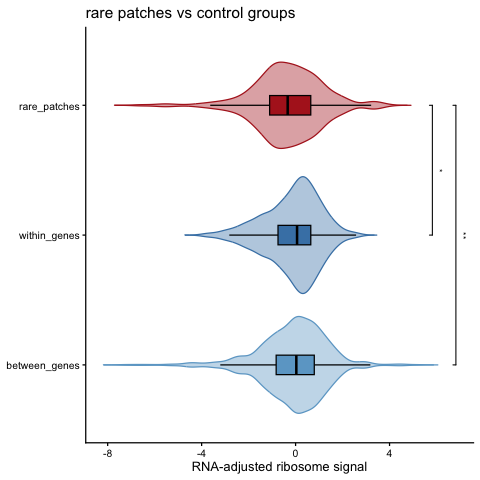

In [16]:
%%R -i df_design_subset

library(dplyr)
library(tidyr)
library(ggplot2)
library(ggsignif)

# Prepare data for plotting with rna_adjusted_ribo
df_plot <- df_design_subset %>%
  filter(!is.na(rna_adjusted_ribo)) %>%
  select(kmer_set, rna_adjusted_ribo) %>%
  rename(group = kmer_set, value = rna_adjusted_ribo) %>%
  mutate(
    group = factor(group, levels = c("between_genes", "within_genes", "rare_patches"))
  )

# creates plot with violin and boxplot
p <- ggplot(df_plot, aes(x = group, y = value, fill = group, color = group)) +
  geom_violin(alpha = 0.4, trim = FALSE) +
  geom_boxplot(width = 0.15, outlier.shape = NA, alpha = 1, color = "black") +
  scale_fill_manual(values = c(
    "rare_patches"   = "firebrick",
    "within_genes"   = "steelblue",
    "between_genes"  = "skyblue3"
  )) +
  scale_color_manual(values = c(
    "rare_patches"   = "firebrick",
    "within_genes"   = "steelblue",
    "between_genes"  = "skyblue3"
  )) +
  labs(x = NULL, y = "RNA-adjusted ribosome signal",
       title = "rare patches vs control groups") +
  theme_classic(base_size = 13) +
  theme(legend.position = "none") +
  geom_signif(
    comparisons = list(
      c("rare_patches", "within_genes"),
      c("rare_patches", "between_genes")
    ),
    method = "t.test",
    map_signif_level = TRUE,
    step_increase = 0.08,
    tip_length = 0.01,
    textsize = 3,
    color = "black"
  ) +
  coord_flip()

# calculates summary statistics
stats_df <- df_plot %>%
  group_by(group) %>%
  summarise(
    mean = mean(value, na.rm = TRUE),
    median = median(value, na.rm = TRUE),
    sd = sd(value, na.rm = TRUE),
    n = n(),
    .groups = 'drop'
  )

# does t-tests
rare_vals <- df_plot$value[df_plot$group == "rare_patches"]
within_vals <- df_plot$value[df_plot$group == "within_genes"]
between_vals <- df_plot$value[df_plot$group == "between_genes"]

test_rare_within <- t.test(rare_vals, within_vals)
test_rare_between <- t.test(rare_vals, between_vals)

# Create test results dataframe
test_results <- data.frame(
  comparison = c("rare_patches vs within_genes", "rare_patches vs between_genes"),
  statistic = c(test_rare_within$statistic, test_rare_between$statistic),
  p_value = c(test_rare_within$p.value, test_rare_between$p.value),
  mean_rare = c(mean(rare_vals), mean(rare_vals)),
  mean_control = c(mean(within_vals), mean(between_vals))
)

# Save plot
ggsave("outputs/figures/figure_2/rare_patch_vs_controls_raincloud_v2.pdf",
       plot = p, width = 7, height = 5, useDingbats = FALSE)

# # Save statistics
# write.csv(stats_df, "outputs/figures/figure_2/rare_patch_vs_controls_statistics.csv", row.names = FALSE)
# write.csv(test_results, "outputs/figures/figure_2/rare_patch_vs_controls_ttest_results.csv", row.names = FALSE)

print("Summary statistics:")
print(stats_df)
print("\nt-test results:")
print(test_results)
p

METAPLOT SECTION 

pipeline:

get kmers made for entire ORFome, map each one to ribosome counts (from before)
then bin by percentile (paramterer)
do it for rare patches relative to between genes controls

also do it for local dip relative to host orf

In [17]:
output_kmers = config['outputs']['files']['output_kmers']['path']
output_kmers

'outputs/files/output_kmers/'

In [18]:

## loads large k-mer file generated in 'get_sequences' to enable window analysis
df_kmers_all = pd.read_csv(output_kmers+'df_kmers_all.csv',index_col=0)

In [19]:
rare_patches = all_kmer_info[all_kmer_info['kmer_set'] =='rare_patches']

rcpgs_list = list(set(rare_patches['host_gene'].dropna()))


len(set((all_kmer_info['host_gene'])))

between_genes = all_kmer_info[all_kmer_info['kmer_set']=='between_genes']

between_genes_list = list(set(between_genes['host_gene'].dropna()))

## gets the between genes list
background_genes = between_genes_list

df_kmers_all['gene']=df_kmers_all.index.str.split('.').str[0]


In [20]:
df_kmers_all['is_rare'] = df_kmers_all['gene'].isin(rcpgs_list)
df_kmers_all['is_background'] = df_kmers_all['gene'].isin(background_genes)

df_kmers_all_subset = df_kmers_all[(df_kmers_all['is_background']==True) | (df_kmers_all['is_rare'] ==True)]


In [21]:
import ast
##   for each row, sum riboseq counts across all genomic locations in coords list
def apply_riboseq_counts_to_kmers(df, bwfile, coords_col='coords', out_col='riboseq_counts'):

    total_tuples = 0
    failed_tuples = 0
    no_data_tuples = 0
    
    def apply_to_row(row):
        nonlocal total_tuples, failed_tuples, no_data_tuples
        
        coords_list = row[coords_col]
        
        # casts coords to actual list of tuples
        if isinstance(coords_list, str):
            coords_list = ast.literal_eval(coords_list)
        
        # check if its None, NaN, or empty
        if coords_list is None or (isinstance(coords_list, float) and pd.isna(coords_list)) or len(coords_list) == 0:
            return float('nan')
        
        total_counts = 0
        valid_counts = False
        
        for coord_tuple in coords_list:
            total_tuples += 1
            try:
                # ensure its exactly 4 values
                assert len(coord_tuple) == 4, f"expected 4 values in tuple, got {len(coord_tuple)}: {coord_tuple}"
                
                chrom, start, end, strand = coord_tuple
                start = int(start)
                end = int(end)
                
                if total_tuples <= 3:
                    print(f"Querying {chrom}:{start}-{end}")
                
                counts = get_riboseq_counts_at_position(chrom, start, end, bwfile)
                
                if total_tuples <= 3:
                    print(f"  Result: {counts}")
                
                if pd.isna(counts):
                    no_data_tuples += 1
                else:
                    total_counts += counts
                    valid_counts = True
            except Exception as e:
                print(f"Error: {e}")
                failed_tuples += 1
                continue
        
        return total_counts if valid_counts else float('nan')
    
    df[out_col] = df.apply(apply_to_row, axis=1)
    
    print(f"total tuples: {total_tuples}")
    print(f"failed tuples: {failed_tuples}")
    print(f"no data tuples: {no_data_tuples}")
    
    return df

In [22]:
# for labelling k-mers, check if a single coordinate overlaps any coordinates in coords_list by more than k percent

def check_single_coord_overlap_with_list(chrom, start, end, coords_list, k=0.5): 
    query_length = end - start
    if query_length <= 0:
        return False
    
    for other_coord in coords_list:
        other_chrom = other_coord[0]
        other_start = int(other_coord[1])
        other_end = int(other_coord[2])
        
        if chrom != other_chrom:
            continue
        
        overlap_start = max(start, other_start)
        overlap_end = min(end, other_end)
        overlap_length = max(0, overlap_end - overlap_start)
        overlap_percent = overlap_length / query_length
        
        if overlap_percent > k:
            return True
    
    return False

#   check if ANY coordinate in coords_in_row overlaps ANY coordinate in coords_list by > k percent
# ## Only checks coordinates from the same gene; uses function above
def check_row_coords_overlap_same_gene(coords_in_row, coords_list, row_gene, k=0.5):

    if isinstance(coords_in_row, str):
        coords_in_row = ast.literal_eval(coords_in_row)
    
    if coords_in_row is None or not coords_in_row:
        return False
    
    # filter coords_list to only same gene
    same_gene_coords = [c for c in coords_list if c[4] == row_gene]  # gene is at index 4
    
    if not same_gene_coords:
        return False
    
    for row_coord in coords_in_row:
        row_chrom = row_coord[0]
        row_start = int(row_coord[1])
        row_end = int(row_coord[2])
        
        if check_single_coord_overlap_with_list(row_chrom, row_start, row_end, same_gene_coords, k):
            return True
    
    return False


In [23]:
combined_df_kmers['gene']=combined_df_kmers['host_gene'].copy()
combined_df_kmers_between = combined_df_kmers[combined_df_kmers['kmer_set']=='between_genes']
combined_df_kmers_within = combined_df_kmers[combined_df_kmers['kmer_set']=='within_genes']


# remakes coords lists with gene information
coords_list_within = list(zip(
    combined_df_kmers_within['chrom'],
    combined_df_kmers_within['start'],
    combined_df_kmers_within['end'],
    combined_df_kmers_within['strand'],
    combined_df_kmers_within['gene']  # Add gene
))

coords_list_between = list(zip(
    combined_df_kmers_between['chrom'],
    combined_df_kmers_between['start'],
    combined_df_kmers_between['end'],
    combined_df_kmers_between['strand'],
    combined_df_kmers_between['gene']  # Add gene
))

In [24]:
# applies to dataframe to subset all k-mers to relevant ones
df_kmers_all_subset['overlaps_within'] = df_kmers_all_subset.apply(
    lambda row: check_row_coords_overlap_same_gene(row['coords'], coords_list_within, row['gene'], k=0.5),
    axis=1
)



In [25]:

df_kmers_all_subset['overlaps_between'] = df_kmers_all_subset.apply(
    lambda row: check_row_coords_overlap_same_gene(row['coords'], coords_list_between, row['gene'], k=0.5),
    axis=1
)

In [26]:
# applies riboseq counts for regions
df_kmers_all_subset = apply_riboseq_counts_to_kmers(
    df_kmers_all_subset, 
    ribo_wig, 
    coords_col='coords', 
    out_col='ribo_counts'
)



Querying chrX:100585019-100585063
  Result: nan
Querying chrX:100585022-100585066
  Result: nan
Querying chrX:100585025-100585066
  Result: nan
total tuples: 1214438
failed tuples: 0
no data tuples: 485830


In [27]:
# applies rna counts to regions
df_kmers_all_subset = apply_riboseq_counts_to_kmers(
    df_kmers_all_subset, 
    rna_wig, 
    coords_col='coords', 
    out_col='rna_counts'
)


Querying chrX:100585019-100585063
  Result: nan
Querying chrX:100585022-100585066
  Result: nan
Querying chrX:100585025-100585066
  Result: nan
total tuples: 1214438
failed tuples: 0
no data tuples: 366544


In [28]:
## labels kmers that have rare patch overlaps
df_kmers_all_subset['is_rare_patch']  = df_kmers_all_subset['rare_codon_count_0']>=8



In [29]:
# table to convert gene ids (can substitute)
id_conv_df = pd.read_csv(config['input_files']['seq_process']['coordinates']['path'])

lookup_common_name = dict(zip(id_conv_df['gene'],id_conv_df['common_name']))
all_human_genes_ensg = list(set(lookup_common_name.keys()))

In [30]:
df_kmers_all_subset['common_name']=df_kmers_all_subset['gene'].map(lookup_common_name)

In [31]:
import ast

# gets strand from coords column
def get_strand_from_coords(coords_str):
    if isinstance(coords_str, str):
        coords_list = ast.literal_eval(coords_str)
    else:
        coords_list = coords_str
    
    if coords_list is None or not coords_list:
        return "+"
    
    # check all tuples for + strand
    for coord in coords_list:
        if len(coord) >= 4 and coord[3] == '+':
            return "+"
    # else '-'
    return "-"

# adds strand column
df_kmers_all_subset['strand'] = df_kmers_all_subset['coords'].apply(get_strand_from_coords)


In [32]:
%R -i df_kmers_all_subset

In [33]:
outdir = config['outputs']['figures']['path']
outdir

'outputs/figures/'

In [34]:
import numpy as np
import pandas as pd

## function to make metaplots for rare codon patch genes and matched background

def create_patch_probability_matrix(df, gene_column='common_name',
                                     position_column='position',
                                     binary_column='is_rare_patch',
                                     value_column='ribo_counts',
                                     n_bins=100,
                                     filter_gene_list=None):
    ## bins each cds into n_bins equal bins to visualize patches
    ## normalization: z-score, (value - gene_mean) / gene_std  (deviation from mean)

    # genes to analyze
    if filter_gene_list is None:
        genes_to_use = df[df[binary_column] == True][gene_column].unique()
    else:
        genes_to_use = filter_gene_list

    # store z-scored values per bin
    bin_feature = {i: [] for i in range(n_bins)}
    bin_values_zscore = {i: [] for i in range(n_bins)}
    gene_dataframes = {}  # processed dataframe for each gene

    for gene in genes_to_use:
        df_gene = df[df[gene_column] == gene].copy()

        if len(df_gene) == 0:
            continue

        # gene statistics
        gene_mean = df_gene[value_column].mean()
        gene_std = df_gene[value_column].std()

        # skip if invalid
        if gene_std == 0 or pd.isna(gene_std) or pd.isna(gene_mean):
            continue

        # z-score normalization
        df_gene[value_column + '_zscore'] = (df_gene[value_column] - gene_mean) / gene_std

        # normalize positions to percentiles
        max_pos = df_gene[position_column].max()
        df_gene['percentile'] = df_gene[position_column] / max_pos

        # bin percentiles
        df_gene['percentile_bin'] = pd.cut(df_gene['percentile'],
                                            bins=n_bins,
                                            labels=range(n_bins),
                                            include_lowest=True)

        # store the processed data of a given gene
        gene_dataframes[gene] = df_gene[[gene_column, position_column, 'percentile',
                                         'percentile_bin', binary_column,
                                         value_column, value_column + '_zscore']].copy()

        # collect data per bin for this gene
        for bin_idx, group in df_gene.groupby('percentile_bin'):
            if pd.notna(bin_idx) and len(group) > 0:
                bin_idx = int(bin_idx)
                # binary feature
                if not group[binary_column].isna().all():
                    bin_feature[bin_idx].append(group[binary_column].iloc[0])
                # z-scored values
                valid_zscore = group[value_column + '_zscore'].dropna().values
                if len(valid_zscore) > 0:
                    bin_values_zscore[bin_idx].extend(valid_zscore)

    # add bin size (nt) and rare patch id to gene dataframes
    for gene in gene_dataframes:
        df_gene = gene_dataframes[gene].sort_values(position_column).reset_index(drop=True)

        # bin size in nucleotides for each bin
        bin_nt_sizes = {}
        for bin_idx in df_gene['percentile_bin'].unique():
            if pd.notna(bin_idx):
                bin_data = df_gene[df_gene['percentile_bin'] == bin_idx]
                min_pos = bin_data[position_column].min()
                max_pos = bin_data[position_column].max()
                bin_size = max_pos - min_pos + 1
                bin_nt_sizes[int(bin_idx)] = bin_size

        df_gene['bin_size_nt'] = df_gene['percentile_bin'].apply(
            lambda x: bin_nt_sizes.get(int(x), np.nan) if pd.notna(x) else np.nan
        )

        # label rare patches for visualization
        patch_ids = []
        patch_counter = 0
        prev_rare = False

        for _, row in df_gene.iterrows():
            if row[binary_column]:
                if not prev_rare:
                    patch_counter += 1
                patch_ids.append(patch_counter)
                prev_rare = True
            else:
                patch_ids.append(np.nan)
                prev_rare = False

        df_gene['rare_patch_id'] = patch_ids
        gene_dataframes[gene] = df_gene

    # per-bin statistics
    result_list = []
    for bin_idx in range(n_bins):
        percentile = bin_idx / n_bins

        # feature probability
        feature_prob = np.mean(bin_feature[bin_idx]) if len(bin_feature[bin_idx]) > 0 else 0

        # z-score statistics
        if len(bin_values_zscore[bin_idx]) > 0:
            mean_zscore = np.mean(bin_values_zscore[bin_idx])
            sem_zscore = np.std(bin_values_zscore[bin_idx]) / np.sqrt(len(bin_values_zscore[bin_idx]))
            n_obs_zscore = len(bin_values_zscore[bin_idx])
        else:
            mean_zscore = np.nan
            sem_zscore = np.nan
            n_obs_zscore = 0

        result_list.append({
            'percentile_bin': bin_idx,
            'percentile': percentile,
            'feature_probability': feature_prob,
            'mean_value_zscore': mean_zscore,
            'sem_value_zscore': sem_zscore,
            'n_observations': n_obs_zscore,
            'n_genes': len(genes_to_use),
            'feature_name': binary_column,
            'value_column': value_column
        })

    result_df = pd.DataFrame(result_list)

    print(f"feature: {binary_column}, values: {value_column}")
    print(f"total genes: {len(genes_to_use)}")
    print("\nz-score normalization ((value - mean) / std):")

    return result_df, gene_dataframes

In [35]:

# Usage:
rare_patch_df, rare_patch_genes = create_patch_probability_matrix(
    df_kmers_all_subset, 
    binary_column='is_rare_patch',
    value_column='ribo_counts',
    n_bins=100
)


feature: is_rare_patch, values: ribo_counts
total genes: 388

z-score normalization ((value - mean) / std):


In [36]:
%%R -i outdir

library(ggplot2)
library(dplyr)
library(zoo)
## function to plot the ribosome occupancy throughout the CDS of a given gene, in counts per nt

plot_ribosome_occupancy_by_gene <- function(df, gene_name,
                                            moving_window = 15,
                                            loess_span = 0.25,
                                            counts_col = "ribo_counts_raw",
                                            binsize_col = "bin_size_nt",
                                            out_file = NULL,
                                            width = 10,
                                            height = 4) {

  df_gene <- df %>%
    filter(common_name == gene_name) %>%
    arrange(position) %>%
    mutate(position = as.numeric(position))

  if (nrow(df_gene) == 0) {
    print(paste("Gene", gene_name, "not found"))
    return(NULL)
  }

  strand <- if ("strand" %in% names(df_gene)) df_gene$strand[1] else NA

  for (col in c(counts_col, binsize_col)) {
    if (!col %in% names(df_gene)) stop(paste("Column not found:", col))
  }

  # counts per nt
  df_gene$counts_per_nt <- df_gene[[counts_col]] / df_gene[[binsize_col]]

  max_pos <- max(df_gene$position, na.rm = TRUE)
  df_gene <- df_gene %>%
    mutate(percentile = position / max_pos) %>%
    arrange(percentile)

  df_gene$ribo_moving_avg <- rollmean(df_gene$counts_per_nt,
                                      k = moving_window, fill = NA, align = "center")

  ## for smoothing
  df_gene_no_na <- df_gene %>% filter(!is.na(counts_per_nt))
  if (nrow(df_gene_no_na) > 0) {
    loess_model <- loess(counts_per_nt ~ percentile, data = df_gene_no_na, span = loess_span)
    df_gene$ribo_loess <- predict(loess_model, newdata = df_gene)
  }

  df_gene$patch_group <- cumsum(df_gene$is_rare_patch != lag(df_gene$is_rare_patch, default = FALSE))

  patch_regions <- df_gene %>%
    filter(is_rare_patch == TRUE) %>%
    group_by(patch_group) %>%
    summarise(patch_start = min(percentile), patch_end = max(percentile), .groups = 'drop')

  title_txt <- if (is.na(strand)) paste("Ribosome Occupancy -", gene_name)
               else paste0("Ribosome Occupancy - ", gene_name, " (", strand, ")")

  p <- ggplot(df_gene, aes(x = percentile)) +
    geom_line(aes(y = counts_per_nt), color = "gray70", linewidth = 0.5, na.rm = TRUE, alpha = 0.7) +
    geom_line(aes(y = ribo_moving_avg), color = "black", linewidth = 1, na.rm = TRUE) +
    geom_line(aes(y = ribo_loess), color = "#1f77b4", linewidth = 1.2, na.rm = TRUE) +
    geom_rect(data = patch_regions,
              aes(xmin = patch_start, xmax = patch_end, ymin = -Inf, ymax = Inf),
              fill = "firebrick", alpha = 0.2, inherit.aes = FALSE) +
    labs(title = title_txt,
         x = "Percentile in CDS (5' to 3')",
         y = "Ribosome Occupancy (counts / nt)") +
    scale_x_continuous(breaks = seq(0, 1, by = 0.25), labels = scales::percent) +
    theme_classic(base_size = 11) +
    theme(plot.title = element_text(hjust = 0.5, face = "bold"))

  if (!is.null(out_file)) ggsave(filename = out_file, plot = p, width = width, height = height)

  p
}


Attaching package: ‘zoo’

The following objects are masked from ‘package:base’:

    as.Date, as.Date.numeric



In [37]:
df_htt = rare_patch_genes['HTT']
df_htt

,common_name,position,percentile,percentile_bin,is_rare_patch,ribo_counts,ribo_counts_zscore,bin_size_nt,rare_patch_id
0,HTT,0,0.000000,0,False,335.0,-0.861094,94,NaN
1,HTT,3,0.000320,0,False,346.0,-0.827145,94,NaN
2,HTT,6,0.000640,0,False,354.0,-0.802455,94,NaN
3,HTT,9,0.000959,0,False,348.0,-0.820972,94,NaN
4,HTT,12,0.001279,0,False,339.0,-0.848749,94,NaN
...,...,...,...,...,...,...,...,...,...
3123,HTT,9369,0.998721,99,False,552.0,-0.191376,94,NaN
3124,HTT,9372,0.999041,99,False,567.0,-0.145083,94,NaN
3125,HTT,9375,0.999360,99,False,567.0,-0.145083,94,NaN
3126,HTT,9378,0.999680,99,False,560.0,-0.166686,94,NaN


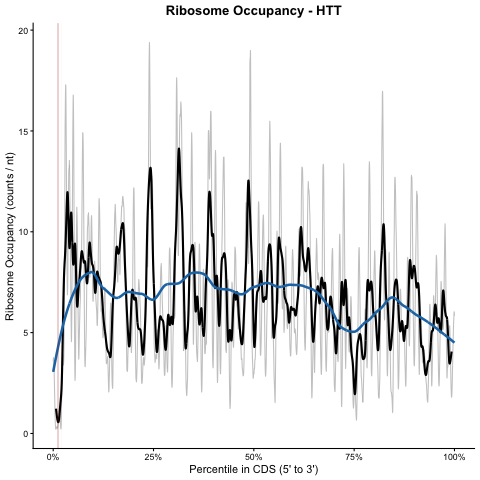

In [38]:
%%R  -i df_htt

res <- plot_ribosome_occupancy_by_gene(df_htt, "HTT",
                                       moving_window = 45,
                                       loess_span = 0.25,counts_col = "ribo_counts",
                                       out_file = paste0(outdir, 'figure_2/riboplot_HTT_per_nt.pdf'))
res

In [39]:
# Between-genes background regions
overlaps_between_df,overlaps_between_genes = create_patch_probability_matrix(
    df_kmers_all_subset, 
    binary_column='overlaps_between',
    value_column='ribo_counts',
    n_bins=100
)

feature: overlaps_between, values: ribo_counts
total genes: 991

z-score normalization ((value - mean) / std):


value / gene_total(value - gene_mean) / gene_std

In [40]:
outdir = config['outputs']['figures']['path']
outdir

'outputs/figures/'

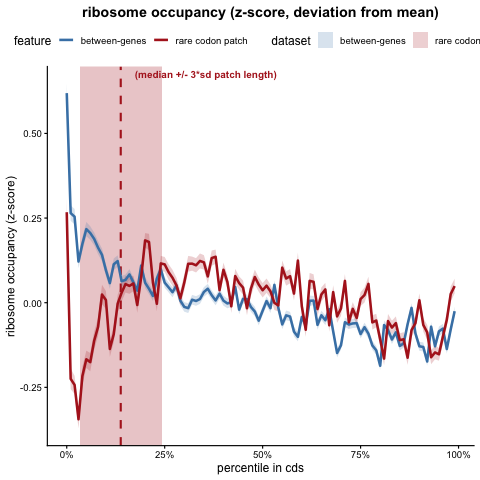

In [41]:
%%R -i rare_patch_df -i overlaps_between_df -i df_master -i outdir

library(ggplot2)
library(dplyr)

# median rare patch percentile from the master dataframe
mean_patch_position <- df_master %>%
  pull(percentile) %>%
  median()

# patch size in percentile, and its sd
df_master <- df_master %>%
  mutate(patch_percentile = nchar(meta_kmer) / nchar(sequence_ORF_original))

sd_patch_percentile <- sd(df_master$patch_percentile)

# extend by 3*sd of patch size on each side (clipped at 0 and 1)
avg_start <- max(0, mean_patch_position - 3 * sd_patch_percentile)
avg_end   <- min(1, mean_patch_position + 3 * sd_patch_percentile)

rare_patch_regions <- tibble(region_start = avg_start, region_end = avg_end)

# combine datasets
df_combined <- bind_rows(
  rare_patch_df %>% mutate(dataset = "rare codon patch"),
  overlaps_between_df %>% mutate(dataset = "between-genes")
)

# metaplot for the z-score normalization
mean_col <- "mean_value_zscore"
sem_col  <- "sem_value_zscore"

p_zscore <- ggplot(df_combined, aes(x = percentile, color = dataset, fill = dataset)) +
  geom_rect(
    data = rare_patch_regions,
    aes(xmin = region_start, xmax = region_end, ymin = -Inf, ymax = Inf),
    fill = "firebrick", alpha = 0.25, inherit.aes = FALSE
  ) +
  geom_vline(
    xintercept = mean_patch_position,
    linetype = "dashed",
    color = "firebrick",
    linewidth = 1
  ) +
  geom_ribbon(
    aes(ymin = !!sym(mean_col) - !!sym(sem_col),
        ymax = !!sym(mean_col) + !!sym(sem_col)),
    alpha = 0.2, color = NA
  ) +
  geom_line(aes(y = !!sym(mean_col)), linewidth = 1.2) +
  scale_color_manual(values = c("rare codon patch" = "firebrick", "between-genes" = "steelblue")) +
  scale_fill_manual(values  = c("rare codon patch" = "firebrick", "between-genes" = "steelblue")) +
  annotate(
    "text",
    x = mean_patch_position,
    y = Inf,
    label = "(median +/- 3*sd patch length)",
    color = "firebrick",
    vjust = 1.5,
    hjust = -0.1,
    fontface = "bold",
    size = 3.5
  ) +
  labs(
    title = "ribosome occupancy (z-score, deviation from mean)",
    x = "percentile in cds",
    y = "ribosome occupancy (z-score)",
    color = "feature"
  ) +
  scale_x_continuous(breaks = seq(0, 1, by = 0.25), labels = scales::percent) +
  theme_classic(base_size = 12) +
  theme(
    plot.title = element_text(hjust = 0.5, face = "bold"),
    legend.position = "top"
  )

print(p_zscore)

ggsave(
  filename = paste0(outdir, "figure_2/ribosome_metaplot_zscore_v2.pdf"),
  plot = p_zscore,
  width = 8,
  height = 5
)

End of riboseq analysis.

# RBP analysis

In [ ]:
import os
import glob
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import random
import pybedtools
from scipy.stats import zscore, fisher_exact, spearmanr, ttest_rel, ttest_ind
from statsmodels.stats.multitest import multipletests
import gzip

In [ ]:
import os
from pathlib import Path

# directory of bed files
bed_dir = Path('outputs/files/output_kmers/')

# dict for bed dfs
bed_dict = {}

# read all the csvs and add them to the bed
for filename in os.listdir(bed_dir):
    if filename.endswith(".bed"):
        filepath = os.path.join(bed_dir, filename)
        
        # Process filename
        kmer_set_name = filename.replace(".bed", "")
        
        # Read bed file
        df = pd.read_csv(filepath, sep='\t', header=None,
                         names=["chrom", "start", "end", "name", "score", "strand"])
        
        bed_dict[kmer_set_name] = df
        print(f"loaded {kmer_set_name}: {df.shape}")



loaded within_genes: (571, 6)
loaded between_genes: (1508, 6)
loaded rare_patches: (482, 6)


In [ ]:
import yaml
from pathlib import Path
import os
import glob

# load config
config_path = Path('configs/read_files/read_files.yaml')
with open(config_path, 'r') as f:
    config = yaml.safe_load(f)

loading_cfg = config['loading_config']

# load gene coordinates
gene_df = pd.read_csv(
    config['input_files']['seq_process']['coordinates']['path'],
    **loading_cfg['csv']
)
print(f"Loaded gene coordinates: {gene_df.shape}")

# load longest ORFs
longest_orfs_df = pd.read_csv(
    config['input_files']['seq_process']['longest_orfs']['path'],
    **loading_cfg['csv']
)
print(f"Loaded longest ORFs: {longest_orfs_df.shape}")

# load master dataframe
df_master = pd.read_csv(
    config['input_files']['kmers']['gene_master']['path'],
    **loading_cfg['csv']
)
print(f"Loaded df_master: {df_master.shape}")

# get rare codon patch genes
rcegs_engs = list(set(df_master['ensg_name_x']))
rcegs = rcegs_engs.copy()

# get protein coding genes
protein_coding_genes = list(set(longest_orfs_df['name']))

# subsets genes to protein-coding ones
gene_df = gene_df[gene_df['gene'].isin(protein_coding_genes)]

# creates bed format dataframe
gene_bed = gene_df.copy()
gene_bed = gene_bed.rename(columns={'gene': 'name'})
gene_bed['score'] = 0
gene_bed = gene_bed[['chrom', 'start', 'end', 'name', 'score', 'strand']]

# dict for bed files of gene coordinates
dfs_bed_genes = {'all_genes': gene_bed}

# subsets to RCEG genes
gene_bed_rcegs = gene_bed[gene_bed['name'].isin(rcegs)]
dfs_bed_genes['rcegs'] = gene_bed_rcegs

# adds gene beds to k-mer beds dictionary
dfs_bed_kmers = bed_dict.copy()
dfs_bed_kmers['all_genes'] = gene_bed
dfs_bed_kmers['rcegs'] = gene_bed_rcegs

# print sample sizes
print("\nK-mer set sample sizes:")
for key in dfs_bed_kmers:
    print(f"  {key}: {len(dfs_bed_kmers[key])} rows")

# assign unique names to duplicates
for key, df in dfs_bed_kmers.items():
    if 'name' in df.columns:
        df['name'] = df['name'] + '_n' + (df.groupby('name').cumcount() + 1).astype(str)

# load RBP eCLIP binding sites
binding_site_directory = Path(config['input_files']['rbps']['eclip_binding']['path'])
rbp_dfs = {}

if binding_site_directory.exists():
    file_pattern = str(binding_site_directory / '*.bed')
    files = glob.glob(file_pattern)
    
    for file in files:
        rbp_name = os.path.basename(file).split('_narrow')[0]
        
        if 'K562' in file:
            cell_type = 'K562'
        elif 'HepG2' in file:
            cell_type = 'HepG2'
        else:
            print(f"Warning: Neither K562 nor HepG2 found in filename: {file}")
            continue
        
        rbp_celltype = f"{rbp_name}_{cell_type}"
        df = pd.read_csv(file, sep='\t', header=None, usecols=[0, 1, 2, 3, 4, 5],
                        names=['chrom', 'start', 'end', 'name', 'score', 'strand'])
        
        rbp_dfs[rbp_celltype] = df
else:
    print(f"RBP directory not found: {binding_site_directory}")

print(f"\nTotal RBPs loaded: {len(rbp_dfs)}")

In [ ]:
def intersector_bed(df_bed1, df_bed2, rbp_name: str, seq_name: str, min_overlap: float, intersection_dict: dict, directory: str):
    """
    purpose: intersects tow bed dfs, one for a given rbp and another for a given kmer list.
    Also updates a dictionary for which two input dfs produced the outputs, and the ratio of intersection for each pair of dfs

    (requires pybedtools)

    df_bed1: first bed df, i.e., the df for a given RBP's binding sites
    df_bed2: the second bed df, i.e., the df of the kmers
    rbp_name: the name of the rbp 
    seq_name: name of the kmer set
    min_overlap: min overlap; a number between 0 and 1.
    intersection_dict: dictionary that stores resulst from intersectoin; can be updated with each new function call. 
    directory: the dir to save the out[ut]
    (returns a df of the intersection with new cols added and the ratio of the intersection sizes)
    """
    
    # loads two dfs for each bed as bedtools objetcts
    bed1 = pybedtools.BedTool.from_dataframe(df_bed1)
    bed2 = pybedtools.BedTool.from_dataframe(df_bed2)

    # performs the intersection in accorance with specified parameters; 
    # r=True ensures that each feature must overlap same proportion of their length
    # wo=True writes the number of base pairs that overlap
    # s=True means strand is accounted for
    # the result intersection will have as many rows as the number of intersecting events (its a bedtool object)
    intersection = bed1.intersect(bed2, wa=False, wb=False, f=min_overlap, r=True, wo=True, s=True)

    # extracts the data that results from the bedtool object and makes it into a pd df
    intersection_data = [x.fields for x in intersection]
    intersection_df = pd.DataFrame(intersection_data)

    # gives a unique key for each rbp that overlaps each kmer
    key = f'{rbp_name}____{seq_name}'

    # if there is no intersection (which may often occur), gives back a placeholder
    if intersection_df.empty:
        intersection_ratio = 0
        intersection_dict[key] = {
            'rbp_df': df_bed1,
            'seq_df': df_bed2,
            'intersection_result': intersection_df,
            'intersection_ratio': intersection_ratio,
            'kmer_counts': {}
        }
        return intersection_df, intersection_ratio, {}

    
    # can save output (not necessary)
    # output_file = f'{directory}/{rbp_name}_{seq_name}_intersection.bed'
    # intersection.saveas(output_file)
    
    # mean kmer lemngth, can normlaize to it
    # mean_kmer_length_in_kmer_set = (df_bed2['end']-df_bed2['start']).mean()

    # gets the ratio of overlap; i.e., number of interecting events (rbp binding evetns) per total number of k-mers; 
    # one is obtained for each rbp when the funciton is called.

    intersection_ratio = len(intersection_df) / (len(df_bed2))

    # gets counts (number of intersecting events);
    # important that col 13, if things are loaded as required, will correspond to the unique k-mer name (now its 9 - may 2026)
    kmer_counts = intersection_df[9].value_counts().to_dict()

    

    # Update the intersection dictionary with the pair of DataFrames that gave rise to the result
    intersection_dict[key] = {
        'rbp_df': df_bed1,
        'seq_df': df_bed2,
        'intersection_result': intersection_df,
        'intersection_ratio': intersection_ratio,
        'kmer_counts': kmer_counts
    }

    return intersection_df, intersection_ratio, kmer_counts
def intersect_all_pairs(rbp_dfs: dict, dfs_bed_kmers: dict, min_overlap: float, intersection_dict: dict, directory: str):
    """
    this now iterates over all pairs (RBPs to kmer set) and computes intersections, with function intersector_bed()

    rbp_dfs: dict of RBP dfs (where the keys are the names of RBPs)
    dfs_bed_kmers: dict of kmer set dfs (keys are the names of the datasets)
    min_overlap: min overlap fraction (number between 0 and 1)
    intersection_dict: dict to store the intersection results, updated in each function all
    directory: directory to save intersection results

    (returns an updated 'intersection dictionary' with results, ratios, and k-mer counts)
    """
    
    # dict to store results generated by functions
    intersection_ratios = {}
    kmer_counts_dict = {}
    # iterates over each pair (rbp_name-seq_name)
    for rbp_name, rbp_df in rbp_dfs.items():
        for seq_name, seq_df in dfs_bed_kmers.items():
            key = f'{rbp_name}____{seq_name}'

            # calls the function on a given pair
            intersection_df, intersection_ratio, kmer_counts = intersector_bed(
                rbp_df, seq_df, rbp_name, seq_name, min_overlap, intersection_dict, directory
            )
            
            # stores result in growing dictionaries
            intersection_ratios[key] = intersection_ratio
            kmer_counts_dict[key] = kmer_counts
    
    # returns resultant dicts
    return intersection_dict, intersection_ratios, kmer_counts_dict

In [ ]:
import pybedtools

# Set directory for saving intersection results
output_directory = 'outputs/files/rbp_intersections/'

# Create directory if it doesn't exist
Path(output_directory).mkdir(parents=True, exist_ok=True)

# runs intersections
intersection_dict = {}
intersection_dict, intersection_ratios, kmer_counts_dict = intersect_all_pairs(
    rbp_dfs=rbp_dfs,
    dfs_bed_kmers=dfs_bed_kmers,
    min_overlap=0.01,  # adjust as needed
    intersection_dict=intersection_dict,
    directory=output_directory
)

print(f"Intersections complete. Results saved to {output_directory}")


Intersections complete. Results saved to outputs/files/rbp_intersections/


In [ ]:
intersection_dict_GENES = {}

# do the same thing but now intersect each rbp binding sites with genes
intersection_dict_GENES, intersection_ratios_GENES, kmer_counts_dict_GENES = intersect_all_pairs(
    rbp_dfs, dfs_bed_genes, min_overlap=0.01, intersection_dict=intersection_dict_GENES, directory=output_directory
)
# 1-2 min

In [ ]:
# Create list to collect all gene-RBP-binding data
data = []

for key, gene_counts in kmer_counts_dict_GENES.items():
    rbp_name = key.split('____')[0]  # extract RBP name from key
    
    for gene_id, binding_count in gene_counts.items():
        data.append({
            'gene': gene_id,
            'rbp': rbp_name,
            'binding_count': binding_count
        })

# create dataframe; gene x rbp shows which genes bind which rbps
df_long_genes_rbps_scores = pd.DataFrame(data)
gene_rbp_binding = df_long_genes_rbps_scores.pivot_table(
    index='gene',
    columns='rbp',
    values='binding_count',
    fill_value=0
)
# table to convert gene ids; for looking up gene common name
id_conv_df = pd.read_csv(config['input_files']['seq_process']['coordinates']['path'])

lookup_common_name = dict(zip(id_conv_df['gene'],id_conv_df['common_name']))
all_human_genes_ensg = list(set(lookup_common_name.keys()))

gene_rbp_binding['gene']=gene_rbp_binding.index.str.split('_').str[0]
gene_rbp_binding['common_name']=gene_rbp_binding['gene'].map(lookup_common_name)

In [ ]:
gene_rbp_binding.to_csv("/Users/jacobfine/Library/CloudStorage/OneDrive-Personal/U of T 2022-2023/Blencowe/Jan_2024_Blencowe/NOV_2024_reanalysis/sequence_analysis_may_2026/compare_backgrounds_codon/outputs/files/rbp_intersections/rbp_gene_table.csv")

In [ ]:
rbp_binding_genes = {}

for rbp in gene_rbp_binding.columns:
    # only keep RBP columns (with HepG2 or K562)
    if 'HepG2' in rbp or 'K562' in rbp:
        genes_with_binding = gene_rbp_binding[gene_rbp_binding[rbp] > 0]['common_name'].tolist()
        rbp_binding_genes[rbp] = set(genes_with_binding)


# to lookup the genes bound by each rbp
lookup_rbp_binding_genes = rbp_binding_genes

In [ ]:
# this will now make a matrix showing the counts of overlaps for each rbp-kmer pair (in a given k-mer set). 
# i.e., k-mer A has 4 overlap events with RBP B in k-mer set C
# (useful to keeping track of results)

# gets list of all rbps
all_rbps = list(set(rbp_dfs.keys()))

df_dict_kmer_by_rbp = {}
for key in dfs_bed_kmers.keys(): # goes through each k-mer set
    kmer_set = list(set(dfs_bed_kmers[key]['name'])) # list of k-mer for the set

    # for each rbp-kmer set match, there is a kmer counts dict (of how many intersection events there were for each kmer)
    # we subset it for each kmer set to generate a unique matrix
    
    subset_kmer_counts_dict  = {kmerset_key.split('____')[0]: kmerdict_value for kmerset_key,kmerdict_value in kmer_counts_dict.items() if key == kmerset_key.split('____')[-1]} # considers counts dicts that are for the kmerset
    # initalizes empty df to fill in with actual k-mer counts
    df = pd.DataFrame(0,index=all_rbps,columns=kmer_set)
    for rbp in subset_kmer_counts_dict.keys():
        kmers_for_rbp = subset_kmer_counts_dict[rbp]
        for kmer, count in kmers_for_rbp.items():
            df.loc[rbp,kmer]=count  # at the rbp, kmer pposition in the df, add the count
    df_dict_kmer_by_rbp[key]=df
    # can now save each df for each intersection
def compute_intersection_ratios(rbp_dfs: dict, dfs_bed_kmers: dict, intersection_ratios: dict):
    """
    organizes intersection results into a neat df

    rbp_dfs: dict where keys are RBP names and values are each df of the bed files for that RBP's binding sites.
    dfs_bed_kmers: dict where keys are kmer set names and values are each df of the bed files for that kmer's loci
    intersection_ratios: where the interesection ratios are stored for a given rbp in a given kmer set
    (returns a df of intersection ratios with RBPs as rows and kmer sets as columns)
    """
    # extracts keys for kmer sets and rbps
    rbp_keys = list(rbp_dfs.keys())
    seq_keys = list(dfs_bed_kmers.keys())

    # creates a to populate with ratio information
    ratios_data = {seq_name: [] for seq_name in seq_keys}

    # populates with ratio information
    for rbp_name in rbp_keys:
        for seq_name in seq_keys:
            ratio_key = f'{rbp_name}____{seq_name}'
            ratios_data[seq_name].append(intersection_ratios.get(ratio_key, 0))  # if no intersection data, fills with zero.

    # converts the dict to a df for analysis
    ratios_df = pd.DataFrame(ratios_data, index=rbp_keys)

    # prints feedback for those RBPs that don't bind any k-mers
    non_binding_rbps = ratios_df[(ratios_df == 0).all(axis=1)].index.tolist()
    
    return ratios_df
# constructs that df for analyzing binding ratios.
ratio_df_kmer =   compute_intersection_ratios(rbp_dfs, dfs_bed_kmers, intersection_ratios)


In [ ]:
# processes the results; for between genes and within genes controls
a = 1  # pseudocount

# Get the column names
within_col = 'within_genes'
between_col = 'between_genes'
rare_col = 'rare_patches'

# Compute averages (these are already single columns, so no need to average)
ratio_df_kmer['control_within'] = ratio_df_kmer[within_col]
ratio_df_kmer['control_between'] = ratio_df_kmer[between_col]
ratio_df_kmer['control_all'] = ratio_df_kmer[[within_col, between_col]].mean(axis=1)

# computes enrichment ratios
ratio_df_kmer['rare_vs_within'] = (ratio_df_kmer[rare_col] + a) / (ratio_df_kmer['control_within'] + a)
ratio_df_kmer['rare_vs_between'] = (ratio_df_kmer[rare_col] + a) / (ratio_df_kmer['control_between'] + a)
ratio_df_kmer['rare_vs_all'] = (ratio_df_kmer[rare_col] + a) / (ratio_df_kmer['control_all'] + a)

# relative binding scores (for selecting top rbps)
ratio_df_kmer['Z_rare_vs_within'] = zscore(ratio_df_kmer['rare_vs_within'])
ratio_df_kmer['Z_rare_vs_between'] = zscore(ratio_df_kmer['rare_vs_between'])
ratio_df_kmer['Z_rare_vs_all'] = zscore(ratio_df_kmer['rare_vs_all'])


In [ ]:
import os
from pathlib import Path

# saves df of the binding scores for each rbp
output_dir = config['outputs']['figures']['path'] + 'rbps/'
os.makedirs(output_dir, exist_ok=True)

# Now save ratio_df_kmer
ratio_df_kmer.to_csv(output_dir + 'ratio_df_kmer.csv')

In [ ]:
from scipy.stats import ttest_rel
from statsmodels.stats.multitest import multipletests
import pandas as pd
import numpy as np

# backgrounds to consider
background_cols = ['control_within', 'control_between']

## cohen's d 
def cohen_d(group1, group2):
    n1, n2 = len(group1), len(group2)
    s1, s2 = np.var(group1, ddof=1), np.var(group2, ddof=1)
    pooled_std = np.sqrt(((n1 - 1)*s1 + (n2 - 1)*s2) / (n1 + n2 - 2))
    return (np.mean(group1) - np.mean(group2)) / pooled_std

# store results of tests
pvals = []
tstats = []
percent_diffs = []
fold_changes = []
cohens_d_list = []
mean_rare_list = []
mean_control_list = []
mean_diffs = []
std_diffs = []

# perform paired t-tests
for col in background_cols:
    t_stat, p_val = ttest_rel(ratio_df_kmer['rare_patches'], ratio_df_kmer[col])
    tstats.append(t_stat)
    pvals.append(p_val)
    
    # calculate means
    mean_rare = ratio_df_kmer['rare_patches'].mean()
    mean_control = ratio_df_kmer[col].mean()
    mean_rare_list.append(mean_rare)
    mean_control_list.append(mean_control)
    
    # calculate fold change (rare / control)
    fold_change = mean_rare / mean_control
    fold_changes.append(fold_change)
    
    # calculate difference
    differences = ratio_df_kmer['rare_patches'] - ratio_df_kmer[col]
    mean_diff = differences.mean()
    std_diff = differences.std()
    mean_diffs.append(mean_diff)
    std_diffs.append(std_diff)
    
    # calculate percent difference
    pct_diff = ((mean_rare - mean_control) / mean_control) * 100
    percent_diffs.append(pct_diff)
    
    # calculate Cohen's d for paired samples
    cohens_d = mean_diff / std_diff
    cohens_d_list.append(cohens_d)

rej, pvals_corrected, _, _ = multipletests(pvals, alpha=0.05, method='fdr_bh')

# make df of results; for comparing binding of rbps to each sequence set.
results_df = pd.DataFrame({
    'comparison': background_cols,
    'mean_rare_patches': mean_rare_list,
    'mean_control': mean_control_list,
    'fold_change': fold_changes,
    'mean_difference': mean_diffs,
    'std_difference': std_diffs,
    't_stat': tstats,
    'cohens_d': cohens_d_list,
    'percent_difference': percent_diffs,
    'raw_pval': pvals,
    'bh_corrected_pval': pvals_corrected,
    'significant': rej
})



In [ ]:
# will now compute the log-odds ratio (LOR) for the binding of each RBP to rcegs relative to background

# filters to binding events assocaited with all genes (for getting LORs)
kmer_counts_dict_GENES_filtered = {key: value for key, value in kmer_counts_dict_GENES.items() if '____all_genes' in key}

# ensures the list of all protein-coding genes and rcegs is defined
protein_coding_set = set(protein_coding_genes)
rceg_set = set(rcegs)

results = []

# goes through each rbp and the genes it binds (as a dict)
for rbp, gene_count_dict in kmer_counts_dict_GENES_filtered.items():
    cleaned_genes = [gene.split('_')[0] for gene in gene_count_dict.keys()]
    bound_genes = set(cleaned_genes) & protein_coding_set
    if len(bound_genes) ==0: # cases where the rbp never binds
        continue
    rcegs_in_universe = rceg_set & protein_coding_set # ensures that rcegs are in protein coding genes


    a = len(bound_genes & rcegs_in_universe) # the number of rbps bound
    if a == 0: # if no rcegs bind
        continue
    b = len(bound_genes - rcegs_in_universe)
    c = len(rcegs_in_universe - bound_genes)
    d = len(protein_coding_set - (bound_genes | rcegs_in_universe))

    contingency = [[a, b], [c, d]]

    # computes odds ratio from this
    odds_ratio, pval = fisher_exact(contingency, alternative='greater')
    odds_ratio_times_bound_genes = odds_ratio*len(bound_genes)
    # gets it into a LOR
    lor = round(np.log(odds_ratio+1e-10),4)

    # updates the results accordingly
    results.append({
        'rbp': rbp,
        'bound_genes': len(bound_genes),
        'a_in_rcegs_and_bound': a,
        'b_bound_not_in_rcegs': b,
        'c_in_rcegs_not_bound': c,
        'd_neither': d,
        'odds_ratio': odds_ratio,
        'p_value': pval,
        'lor': lor,
        'overall_score':odds_ratio_times_bound_genes
    })

# makes a df of the results and processes it
df_odds = pd.DataFrame(results)
df_odds['rbp'] =df_odds['rbp'].str.split('____').str[0]

# applies BH correction
bh_corrected = multipletests(df_odds['p_value'], method='fdr_bh')
df_odds['p_value_bh'] = bh_corrected[1]

In [ ]:
%R -i ratio_df_kmer

In [ ]:
ratio_df_kmer

,within_genes,between_genes,rare_patches,all_genes,rcegs,control_within,control_between,control_all,rare_vs_within,rare_vs_between,rare_vs_all,Z_rare_vs_within,Z_rare_vs_between,Z_rare_vs_all
DDX55_HepG2,0.000000,0.001326,0.004149,0.015035,0.032995,0.000000,0.001326,0.000663,1.004149,1.002819,1.003484,0.293913,0.469856,0.411833
NIP7_HepG2,0.000000,0.000000,0.000000,0.000396,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,-0.279882,-0.217881,-0.293093
SF3B4_K562,0.001751,0.000663,0.004149,0.029970,0.025381,0.001751,0.000663,0.001207,1.002394,1.003484,1.002939,0.051154,0.631964,0.301493
hnRNPM_HepG2,0.000000,0.000663,0.006224,0.002522,0.002538,0.000000,0.000663,0.000332,1.006224,1.005557,1.005891,0.580811,1.137712,0.898776
FXR2_HepG2,0.007005,0.003316,0.004149,0.000940,0.002538,0.007005,0.003316,0.005160,0.997164,1.000831,0.998994,-0.672058,-0.015180,-0.496619
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
RBM5_HepG2,0.000000,0.000000,0.000000,0.002028,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,-0.279882,-0.217881,-0.293093
SUPV3L1_K562,0.000000,0.000000,0.000000,0.000396,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,-0.279882,-0.217881,-0.293093
SF3B4_HepG2,0.001751,0.000000,0.000000,0.023788,0.032995,0.001751,0.000000,0.000876,0.998252,1.000000,0.999125,-0.521638,-0.217881,-0.470114
UPF1_HepG2,0.010508,0.003979,0.012448,0.052720,0.101523,0.010508,0.003979,0.007243,1.001920,1.008436,1.005167,-0.014365,1.839881,0.752452


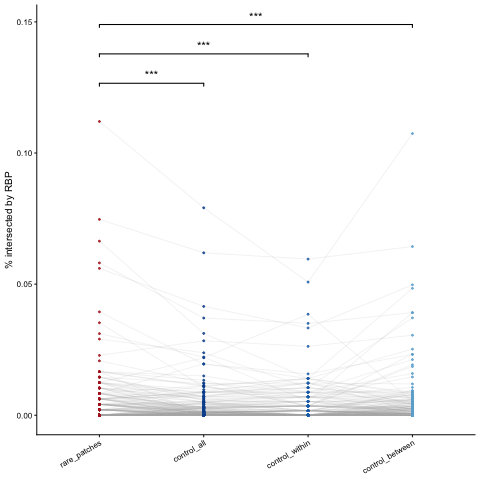

In [ ]:
%%R

## plot to show binding preferences of rare codon patches relative to matched controls

library(ggplot2)
library(dplyr)
library(tidyr)
library(ggsignif)

df_subset <- ratio_df_kmer %>%
  select(rare_patches, control_within, control_between, control_all) %>%
  mutate(meta_kmer_id = row_number())

grp_levels <- c("rare_patches", "control_all", "control_within", "control_between")

df_long <- df_subset %>%
  pivot_longer(cols = -meta_kmer_id, names_to = "group", values_to = "score") %>%
  mutate(group = factor(group, levels = grp_levels))

star <- function(p) ifelse(p < 0.001, "***", ifelse(p < 0.01, "**", ifelse(p < 0.05, "*", "ns")))

p_all     <- t.test(df_subset$rare_patches, df_subset$control_all,     paired = TRUE)$p.value
p_within  <- t.test(df_subset$rare_patches, df_subset$control_within,  paired = TRUE)$p.value
p_between <- t.test(df_subset$rare_patches, df_subset$control_between, paired = TRUE)$p.value

y_max <- max(df_long$score, na.rm = TRUE)
y_rng <- diff(range(df_long$score, na.rm = TRUE))

p_multi <- ggplot(df_long, aes(x = group, y = score, group = meta_kmer_id)) +
  geom_line(color = "gray70", alpha = 0.15) +
  geom_point(aes(color = group), size = 0.6, alpha = 0.8) +
  scale_color_manual(values = c(
    "rare_patches"    = "firebrick",
    "control_all"     = "#08519c",
    "control_within"  = "#2171b5",
    "control_between" = "#6baed6"
  )) +
  geom_signif(
    comparisons = list(
      c("rare_patches", "control_all"),
      c("rare_patches", "control_within"),
      c("rare_patches", "control_between")
    ),
    annotations = c(star(p_all), star(p_within), star(p_between)),
    y_position  = y_max + y_rng * c(0.08, 0.18, 0.28),
    tip_length  = 0.01,
    textsize    = 4,
    color       = "black"
  ) +
  labs(x = NULL, y = "% intersected by RBP") +
  theme_classic(base_size = 10) +
  theme(
    legend.position = "none",
    panel.grid.major.x = element_blank(),
    axis.text.x = element_text(angle = 30, hjust = 1)
  )


ggsave(
  filename = 'outputs/figures/figure_s2/binding_enrichments_kmers.pdf',
  plot = p_multi,
  width = 6,
  height = 4
)
p_multi

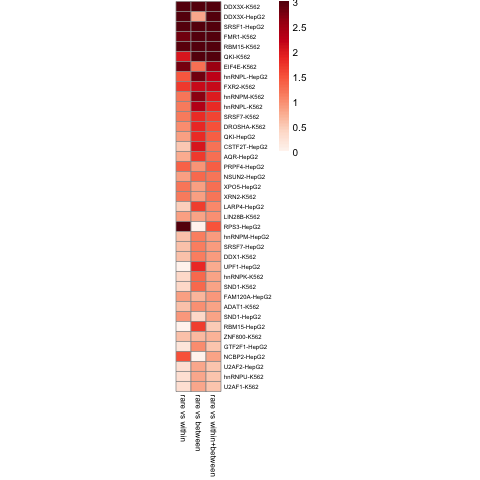

In [ ]:
%%R

library(dplyr)
library(pheatmap)
library(RColorBrewer)

df <- ratio_df_kmer

# select the zscore cols
z_cols <- grep("^Z_", colnames(df), value = TRUE)

# builds matrix and assign rownames
z_matrix <- df %>%
  select(all_of(z_cols)) %>%
  as.data.frame()
if ("rbp" %in% colnames(df)) {
  rownames(z_matrix) <- df$rbp
}

# filter to rows with positive average enrichment (for display)
row_means <- rowMeans(z_matrix, na.rm = TRUE)
z_matrix_filtered <- z_matrix[row_means > 0.5, , drop = FALSE]


# renames axes accordingly
new_colnames <- c(
  Z_rare_vs_within       = "rare vs within",
  Z_rare_vs_between      = "rare vs between",
  Z_rare_vs_all          = "rare vs within+between"
)
colnames(z_matrix_filtered) <- new_colnames[colnames(z_matrix_filtered)]
rownames(z_matrix_filtered) <- gsub("_", "-", rownames(z_matrix_filtered))

# Sort rows by average z-score
row_means <- rowMeans(z_matrix_filtered, na.rm = TRUE)
z_matrix_filtered <- z_matrix_filtered[order(row_means, decreasing = TRUE), ]
dir.create("outputs/figures/figure_3", showWarnings = FALSE, recursive = TRUE)

# defines color palette (now starting from 0)
vmin <- 0
vmax <- 3
breaks <- seq(vmin, vmax, length.out = 101)
colors <- colorRampPalette(brewer.pal(9, "Reds"))(100)
# Save heatmap
pheatmap::pheatmap(
  z_matrix_filtered,
  color = colors,
  breaks = breaks,
  scale = "none",
  cluster_rows = FALSE,
  cluster_cols = FALSE,
  show_rownames = TRUE,
  show_colnames = TRUE,
  fontsize_row = 6,
  fontsize_col = 8,
  cellwidth = 15,
  cellheight = 10,
  # filename = "outputs/figures/figure_3/binding_heatmap_v3.pdf"
)



In [ ]:
# integrate the results with GTEx mRNA expression data

gtex_path = config['input_files']['expression']['gtex']['path']

with gzip.open(gtex_path, 'rt') as f:
    # reads it into a df
    df_GTEx = pd.read_csv(
        f,   # make it on the openned file object
        low_memory=False,
        delimiter='\t',
        skiprows=2  
    )

    # takes 2-3 min

In [ ]:
# passes metadata on gtex (can substitute)
df_metadata = pd.read_csv(config['input_files']['expression']['gtex_metadata']['path'],delimiter='\t')
df_metadata.columns

# looks up tissue into the study it was from
lookup_tissue = dict(zip(df_metadata['external_id'],df_metadata['study']))
# table to convert gene ids (can substitute)
id_conv_df = pd.read_csv(config['input_files']['seq_process']['coordinates']['path'])

lookup_common_name = dict(zip(id_conv_df['gene'],id_conv_df['common_name']))
all_human_genes_ensg = list(set(lookup_common_name.keys()))

# subsets to protien coding genes


all_coding_genes = list(set(df_longest_orf['name']))


df_GTEx['is_coding']  = df_GTEx['Name'].str.split('.').str[0].isin(all_coding_genes)

df_GTEx_copy = df_GTEx[df_GTEx['is_coding']]

# keeps track of gtex cols
gtex_cols = [col for col in df_GTEx_copy.columns if 'GTEX' in col]
df_GTEx_copy['is_mit'] = df_GTEx_copy['Description'].str.contains('MT-') # also keeps track of mit genes

df_GTEx_copy = df_GTEx_copy[df_GTEx_copy['is_mit']==False] # drops mit genes
# averages over samples in same tissue, by grouping cols from same tissues

df_GTEx_copy.set_index('Description',inplace=True)


grouped_cols = {}
for col in gtex_cols:
    col = col + '.1' # makes format compatible
    if col in lookup_tissue.keys():

        tissue = lookup_tissue[col]
        col = col.split('.1')[0]
        grouped_cols.setdefault(tissue, []).append(col)

df_GTEX_av = pd.DataFrame()
for tissue, cols in grouped_cols.items():
    df_GTEX_av[tissue] = df_GTEx_copy[cols].mean(axis=1)


grouped_cols_set = set()  # tracks grouped cols
for tissue, cols in grouped_cols.items():
    df_GTEX_av[tissue] = df_GTEx_copy[cols].mean(axis=1)
    grouped_cols_set.update(cols)  # adds grouped columns to the set


# adds back cols that werent grouped
for col in df_GTEx_copy.columns:
    if col not in grouped_cols_set:
        df_GTEX_av[col] = df_GTEx_copy[col]

## subsets to coding genes only
df_GTEX_av = df_GTEX_av[df_GTEX_av['is_coding']==True]
df_GTEX_av

In [ ]:
## can read the previous ratio_df_kmer file
ratio_df_kmer = pd.read_csv(config['outputs']['figures']['path'] + 'rbps/ratio_df_kmer.csv',index_col=0)

In [ ]:
rbp_cols =[col for col in df_master if '_K562' in col or '_HepG2' in col]

# to get top binding rcegs
Z=1.96 # 
df_master_merge_rbp = df_master[['gene','meta_kmer_id','length_in_nt'] + rbp_cols]
# total number of bidning events divided by length of each kmer, then z-normalize it
df_master_merge_rbp['norm_sum_rbp_binding'] =round(df_master_merge_rbp[rbp_cols].sum(axis=1)/df_master_merge_rbp['length_in_nt'],4)  # total binding events per base per kmer
df_master_merge_rbp['Z_norm_sum_rbp_binding'] = zscore(df_master_merge_rbp['norm_sum_rbp_binding'])
top_rcegs_binding_rbps = list(set(df_master_merge_rbp[df_master_merge_rbp['Z_norm_sum_rbp_binding']>Z]['gene'].dropna()))



In [ ]:
Z=1.96
ratio_df_kmer_top_z1 = ratio_df_kmer[ratio_df_kmer['Z_rare_vs_all'] > Z]  
top_rbps_z1 = list(set(ratio_df_kmer_top_z1.index.str.split('_').str[0]))
## top binding rbps
top_rbps_z1 

['RBM15', 'EIF4E', 'hnRNPL', 'SRSF1', 'hnRNPM', 'QKI', 'DDX3X', 'FMR1', 'FXR2']

In [ ]:
## gene names of each of the rbps
all_rbps_gene = list(set([rbp.split('_')[0] for rbp in rbp_cols]))
rcegs_common = list(set(df_master['common_name_x']))
all_genes_GTEX = list(set(df_GTEX_av.index))
len(all_rbps_gene)

168

In [ ]:
genes_GC_len_sample = pd.read_csv(config['outputs']['files']['output_kmers']['path']+'genes_GC_len_sample.csv')
gc_len_genes = list(set(genes_GC_len_sample['name']))
len(gc_len_genes)
## gc-length matched genes
gc_len_genes_list_common= [lookup_common_name[g] for g in gc_len_genes if lookup_common_name[g]  != np.nan]
len(gc_len_genes_list_common)

all_coding_gtex = list(set(df_GTEX_av.index)) ## all coding genes in the gtex data

716

In [ ]:
## various gene lists to look at expression
gene_list_dict = {'background_gc_v2':gc_len_genes,'background_gc_v2_commmon':gc_len_genes_list_common,'top_rcegs_binding_rbps':top_rcegs_binding_rbps,
'rceg':rcegs_common,'all_rbps_gene':all_rbps_gene,'top_rbps_z1':top_rbps_z1}

gene_list_dict_overlap_gtex = {
    key: [gene for gene in gene_list if gene in all_genes_GTEX]
    for key, gene_list in gene_list_dict.items()
}

In [ ]:
## tissue columns
tissue_cols_checked = list(df_GTEX_av.columns[:30])


In [ ]:
# tissue cols to use from GTEx (30 total)
tissue_cols_checked = list(df_GTEX_av.columns[:30])

# transpose so rows = tissues, cols = genes
df_GTEX_av_T = df_GTEX_av[tissue_cols_checked].T
df_GTEX_av_T = df_GTEX_av_T[all_genes_GTEX]

# generate gene-gene Spearman/Pearson correlatoins

# df_GTEX_av_T_corr = df_GTEX_av_T.corr(method='spearman')

df_GTEX_av_T_corr = df_GTEX_av_T.corr(method='pearson')

# runs correlations on different sets

In [ ]:
import numpy as np

# gets the pairwise correlations between two gene sets
def get_corr_col_A_col_B(col_a, col_b):
    list_a = gene_list_dict_overlap_gtex[col_a]
    list_b = gene_list_dict_overlap_gtex[col_b]

    # subset precomputed correlation matrix
    df_corr_a_b = df_GTEX_av_T_corr.loc[list_a, list_b]
    # Use nanmean to ignore NaN values (equivalent to na.rm=TRUE in R)
    corr = np.nanmean(df_corr_a_b.values)

    print(col_a, col_b)
    print(f"Mean correlation: {round(corr, 4)}")

    return df_corr_a_b

perm tests

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

## computes a permutation test to determine if a subset of a gene list is enriched for co-expression

_pos = {g: i for i, g in enumerate(df_GTEX_av_T_corr.index)} ## matrix of the indices of each gene in the corr matrix
_m   = df_GTEX_av_T_corr.values.astype(float) ## the values of the matrix

def _idx(key_or_genes):
    genes = gene_list_dict_overlap_gtex[key_or_genes] if isinstance(key_or_genes, str) else key_or_genes
    return np.array([_pos[g] for g in genes if g in _pos], dtype=int)

def block_mean_corr_idx(ia, ib, use_abs=False):
    # mean pairwise corr between two sets, masking self-pairs (and lower triangle if within-set)
    sub = _m[np.ix_(ia, ib)].copy()
    if use_abs:
        sub = np.abs(sub)
    sub[ia[:, None] == ib[None, :]] = np.nan      # masks diagonal
    if len(ia) == len(ib) and np.array_equal(ia, ib):  # if a square matrix, drop lower triangle
        for i in range(len(ia)):
            sub[i, :i] = np.nan
    return np.nanmean(sub)


def perm_test_nested_cross(top_a, parent_a, top_b, parent_b,
                           n_perm=1000, seed=0, tail="", plot=True):
    rng = np.random.default_rng(seed)
    ta, tb = _idx(top_a), _idx(top_b)
    pa = np.unique(np.concatenate([_idx(parent_a), ta]))   
    pb = np.unique(np.concatenate([_idx(parent_b), tb]))
    na, nb = len(ta), len(tb)  #  get the sizes of each gene set, used for sample size in perm test

    obs = block_mean_corr_idx(ta, tb)

    ## at each iteration, sample two differnet gene lists of equal size from the parent combined list
    ## compare the correlation 
    null = np.empty(n_perm)
    for k in range(n_perm):
        sa = rng.choice(pa, size=na, replace=False)
        sb = rng.choice(pb, size=nb, replace=False)
        ## keeps track of the average corr valiue from each gene set
        null[k] = block_mean_corr_idx(sa, sb)  # random nested subsets

    null = null[np.isfinite(null)]
    n_eff = null.size

    if   tail == "greater": pval = (1 + np.sum(null >= obs)) / (n_eff + 1)
    elif tail == "less":    pval = (1 + np.sum(null <= obs)) / (n_eff + 1)
    else:
        c = null.mean()
        ## emprical -value from null
        pval = (1 + np.sum(np.abs(null - c) >= abs(obs - c))) / (n_eff + 1)

    print(f"observed cross corr [{top_a} x {top_b}] = {obs:.4f}")
    print(f"null mean cross corr = {null.mean():.4f}")
    print(f"difference from null          = {obs - null.mean():.4f}")
    print(f"p ({tail or 'two-sided'}) = {pval:.4g}")

    return obs, pval, null


In [ ]:
# Usage example:
obs, pval, null = perm_test_nested_cross(
    'top_rcegs_binding_rbps', 'rceg',
    'top_rcegs_binding_rbps',  'rceg')

observed cross corr [top_rcegs_binding_rbps x top_rcegs_binding_rbps] = 0.4403
null mean cross corr = 0.1603
difference from null          = 0.2800
p (two-sided) = 0.000999


In [ ]:
df_rceg_rceg = get_corr_col_A_col_B('rceg','rceg')
df_toprceg_toprceg = get_corr_col_A_col_B('top_rcegs_binding_rbps','top_rcegs_binding_rbps')

rceg rceg
Mean correlation: 0.1619
top_rcegs_binding_rbps top_rcegs_binding_rbps
Mean correlation: 0.4683


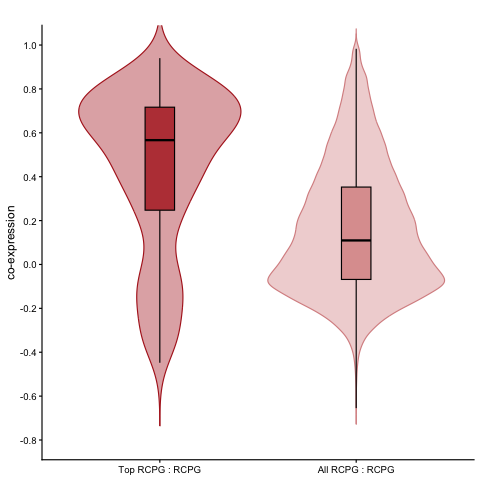

In [ ]:
%%R -i df_rceg_rceg -i df_toprceg_toprceg


## for plotting the results of the corr test.


library(ggplot2)
library(dplyr)

lighten_color <- function(color, factor = 0.5) {
  col <- col2rgb(color) / 255
  col <- col + (1 - col) * factor
  rgb(col[1], col[2], col[3])
}

dark_red  <- "firebrick"
light_red <- lighten_color(dark_red, factor = 0.5)

all_values <- function(df, remove_diag = FALSE) {
  m <- as.matrix(df)
  if (remove_diag) {
    common <- intersect(rownames(m), colnames(m))
    for (g in common) m[g, g] <- NA
  }
  v <- as.vector(m)
  v[!is.na(v)]
}

lab_all <- "All RCPG : RCPG"
lab_top <- "Top RCPG : RCPG"

d <- bind_rows(
  data.frame(value = all_values(df_rceg_rceg, remove_diag = TRUE), group = lab_all),
  data.frame(value = all_values(df_toprceg_toprceg, remove_diag = TRUE), group = lab_top)
) %>% filter(!is.na(value))
d$group <- factor(d$group, levels = c(lab_top, lab_all)) 

cols <- setNames(c(light_red, dark_red), c(lab_all, lab_top))

p_rceg <- ggplot(d, aes(x = group, y = value, fill = group, color = group)) +
  geom_violin(alpha = 0.4, trim = FALSE) +
  geom_boxplot(width = 0.15, outlier.shape = NA, alpha = 0.8, color = "black") +
  scale_fill_manual(values = cols) +
  scale_color_manual(values = cols) +
  scale_y_continuous(breaks = round(seq(-0.8, 1, by = 0.2), 1)) +
  labs(y = "co-expression", x = NULL, title = "") +
  theme_classic(base_size = 12) +
  theme(legend.position = "none") +
  coord_cartesian(ylim = c(-0.8, 1))

ggsave("outputs/figures/figure_3/coexp_rceg_rceg.pdf", p_rceg, width = 4, height = 5)
p_rceg

In [ ]:

df_allrceg_allrceg = get_corr_col_A_col_B('rceg','rceg')


df_allrceg_allrceg = df_allrceg_allrceg.reset_index() # ready to plot the rceg by rceg matrix.
%R -i df_allrceg_allrceg -i top_rcegs_binding_rbps

rceg rceg
Mean correlation: 0.1619


[1] "Matrix dim: 369 x 369"


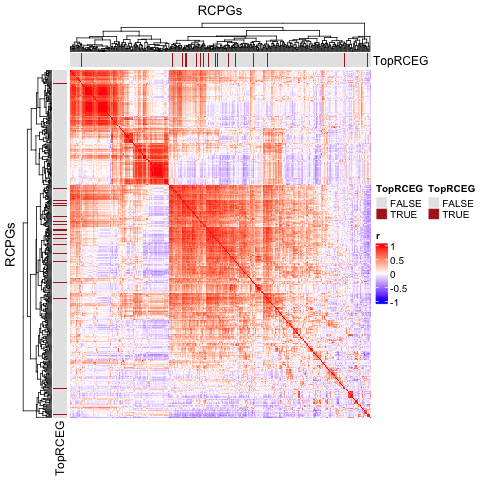

In [ ]:
%%R

## to draw the co-expression heatmap with labelled RBP info

library(ComplexHeatmap)
library(circlize)
library(dplyr)
library(grid)

# convert to matrix and remove Description column
cor_matrix <- as.matrix(df_allrceg_allrceg[, -1])  # remove first column
rownames(cor_matrix) <- df_allrceg_allrceg$Description

print(paste("Matrix dim:", nrow(cor_matrix), "x", ncol(cor_matrix)))

# defines top rcegs to highlight
top_rcegs_clean <- top_rcegs_binding_rbps

# defines annotation bars for top rcegs
rceg_rows_in_top <- rownames(cor_matrix) %in% top_rcegs_clean
rceg_cols_in_top <- colnames(cor_matrix) %in% top_rcegs_clean

row_annot <- rowAnnotation(
  TopRCEG = rceg_rows_in_top,
  col = list(TopRCEG = c("TRUE" = "firebrick", "FALSE" = "grey90")),
  width = unit(4, "mm")
)

col_annot <- HeatmapAnnotation(
  TopRCEG = rceg_cols_in_top,
  col = list(TopRCEG = c("TRUE" = "firebrick", "FALSE" = "grey90")),
  height = unit(4, "mm")
)

# sets color scale
col_fun <- colorRamp2(c(-1, 0, 1), c("blue", "white", "red"))

# makes heatmap
ht <- Heatmap(
  cor_matrix,
  name = "r",
  col = col_fun,
  show_row_names = FALSE,
  show_column_names = FALSE,
  cluster_rows = TRUE,
  cluster_columns = TRUE,
  left_annotation = row_annot,
  top_annotation = col_annot,
  column_title = "RCPGs",
  row_title = "RCPGs"
)


# # # can save results
# pdf('outputs/figures/figure_3/rcpgs_rcpgs_gtex.pdf', 
#     width = 6, height = 6)

draw(ht)




### Analysis of knockdown data

In [44]:
config['input_files']['rbps']['differential_expression']['path']

'input_files/rbps/RBP_differential_expression/master_df_rbp_world_may.csv'

In [45]:
final_df = pd.read_csv(config['input_files']['rbps']['differential_expression']['path'])


In [46]:
ratio_df_kmer = pd.read_csv(config['outputs']['figures']['path'] + 'rbps/ratio_df_kmer.csv',index_col=0)

In [51]:
Z=1.96
ratio_df_kmer_top_z1 = ratio_df_kmer[ratio_df_kmer['Z_rare_vs_all'] > Z] 
top_rbps_z1_full_name = list(set(ratio_df_kmer_top_z1.index))

# top_rbps_z1_full_name_from_before = top_rbps_z1 ## earlier one (above)
top_rbps_z1_full_name_from_before = top_rbps_z1_full_name ## earlier one (above)

In [52]:
import RNA
## added may 2026

def get_mfe(seq):
    structure, mfe = RNA.fold(seq)
    return mfe

df_master['meta_kmer'].str.len().describe()
df_master['MFE'] =  df_master['meta_kmer'].apply(get_mfe)

In [53]:
NC_cols = [col for col in final_df.columns if 'NC_' in col] 

ratio_df_kmer['rbp'] = ratio_df_kmer.index
lookup_Z_rate_rbp = dict(zip(ratio_df_kmer['rbp'],ratio_df_kmer['Z_rare_vs_all']))

fold_change_master_rbp_world = final_df.copy()

Highly structured mean abs log2FC = 0.763, n = 180
Low-structure mean abs log2FC = 0.490, n = 182
t-test p-value = 7.409e-03


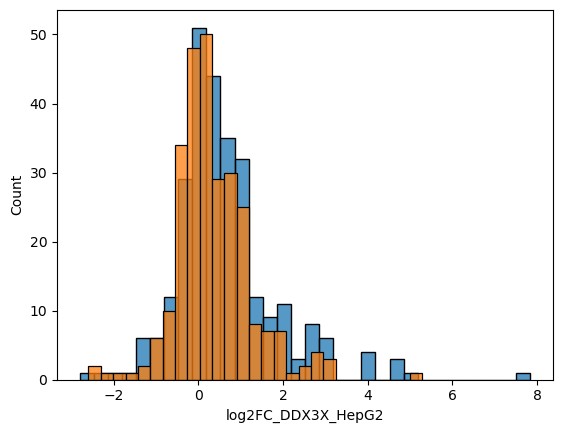

In [54]:
ex_cols_rbps_shRNA  = [col for col in fold_change_master_rbp_world.columns if ('shRNA' in col) and ('siRNA' not in col) and ('CRISPR' not in col)]  # only looking at shRNA

replace_dict = {col: col.replace('_shRNA','') for col in ex_cols_rbps_shRNA}
fold_change_master_rbp_world['gene_new'] = fold_change_master_rbp_world['gene'].str.split(f"(").str[0]
fold_change_master_rbp_world.rename(columns=replace_dict, inplace=True)
id_conv_df = pd.read_csv(config['input_files']['seq_process']['coordinates']['path'])

all_human_genes = list(set(id_conv_df['common_name']))
len(all_human_genes)

fold_change_master_rbp_world = fold_change_master_rbp_world[fold_change_master_rbp_world['gene_new'].isin(all_human_genes)]

rbp_name_cols = [col.replace('log2FC_','') for col in fold_change_master_rbp_world.columns if 'log2FC' in col]


fold_change_master_rbp_world.set_index('gene_new',inplace=True)

rbp_cols = [col for col in df_master.columns if 'K562' in col or 'HepG2' in col]
len(rbp_cols)

# common_rbps_clip_shrna = list(set.intersection(set(rbp_name_cols),set(rbp_gene_dict.keys())))


common_rbps_clip_shrna = list(set.intersection(set(rbp_name_cols),set(rbp_cols))) # the change is rbp_cols, now 242; butnow 181! good.

len(common_rbps_clip_shrna)

foldchange_cols = [col for col in fold_change_master_rbp_world.columns if 'log2FC' in col]

fold_change_master_rbp_world_fc = fold_change_master_rbp_world[foldchange_cols]


fold_change_master_rbp_world_fc.columns = fold_change_master_rbp_world_fc.columns.str.replace("-Jacob’s MacBook Pro", "", regex=False)
fold_change_master_rbp_world_fc



## for DDX3X analysis

ddx3x_cols = [col for col in fold_change_master_rbp_world_fc.columns if 'DDX3X' in col]
ddx3x_fold_change_df = fold_change_master_rbp_world_fc[ddx3x_cols]

lookup_rcpg_mfe =  dict(zip(df_master['gene'],df_master['MFE'] ))
rcpgs = list(set(df_master['gene']))

ddx3x_fold_change_df['is_rcpg']= ddx3x_fold_change_df.index.isin(rcpgs)
ddx3x_fold_change_df['MFE']= ddx3x_fold_change_df.index.map(lookup_rcpg_mfe)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import ttest_ind

ddx3x_fold_change_df_rcpg = ddx3x_fold_change_df[ddx3x_fold_change_df['is_rcpg']]
sns.histplot(ddx3x_fold_change_df_rcpg['log2FC_DDX3X_HepG2'])
sns.histplot(ddx3x_fold_change_df_rcpg['log2FC_DDX3X_K562'])

# pool tissues
df = ddx3x_fold_change_df_rcpg[
    ['log2FC_DDX3X_K562', 'log2FC_DDX3X_HepG2', 'MFE']
].copy()

# replace infinities
df = df.replace([np.inf, -np.inf], np.nan)
df['log2FC_DDX3X_K562'] = df['log2FC_DDX3X_K562'].fillna(0)
df['log2FC_DDX3X_HepG2'] = df['log2FC_DDX3X_HepG2'].fillna(0)

# keep only rows with valid MFE
df = df.dropna(subset=['MFE'])

# pool cell lines
df_k562 = df[['log2FC_DDX3X_K562', 'MFE']].rename(
    columns={'log2FC_DDX3X_K562': 'log2FC'}
)
df_hepg2 = df[['log2FC_DDX3X_HepG2', 'MFE']].rename(
    columns={'log2FC_DDX3X_HepG2': 'log2FC'}
)

df_pooled = pd.concat([df_k562, df_hepg2], ignore_index=True)

df_pooled['abs_log2FC'] = df_pooled['log2FC'].abs()

# bin by quantile
bottom_10_thresh = df_pooled['MFE'].quantile(0.25)
top_10_thresh = df_pooled['MFE'].quantile(0.75)

# groups
high_structure = df_pooled[
    df_pooled['MFE'] <= bottom_10_thresh
]['abs_log2FC']

low_structure = df_pooled[
    df_pooled['MFE'] >= top_10_thresh
]['abs_log2FC']

# perform ttest to compare the transcripts levels
t_stat, p_val = ttest_ind(
    high_structure,
    low_structure,
    equal_var=False,
    alternative='two-sided'
)

print(f"Highly structured mean abs log2FC = {high_structure.mean():.3f}, n = {len(high_structure)}")
print(f"Low-structure mean abs log2FC = {low_structure.mean():.3f}, n = {len(low_structure)}")
print(f"t-test p-value = {p_val:.3e}")



In [55]:
%load_ext rpy2.ipython

The rpy2.ipython extension is already loaded. To reload it, use:
  %reload_ext rpy2.ipython


High structure mean abs log2FC = 0.8260057 , n = 167 
Low structure mean abs log2FC = 0.5280335 , n = 169 
t-test p-value = 0.005712188 
Cohen's d = 0.3049143 
Plot saved to: outputs/figures/figure_misc/ddx3x_pooled_mfe_structure.pdf 


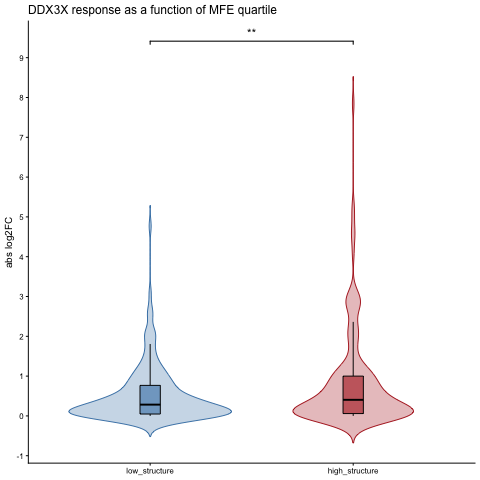

In [56]:
%%R -i ddx3x_fold_change_df_rcpg


### visualize cahnge in log2FC upon DDX3X knockdown.

library(ggplot2)
library(dplyr)
library(tidyr)
library(scales)
library(ggsignif)

df <- ddx3x_fold_change_df_rcpg %>%
  select(log2FC_DDX3X_K562, log2FC_DDX3X_HepG2, MFE) %>%
  mutate(
    log2FC_DDX3X_K562 = ifelse(is.na(log2FC_DDX3X_K562), 0, log2FC_DDX3X_K562),
    log2FC_DDX3X_HepG2 = ifelse(is.na(log2FC_DDX3X_HepG2), 0, log2FC_DDX3X_HepG2)
  ) %>%
  filter(is.finite(MFE))

df_pooled <- bind_rows(
  df %>% select(log2FC = log2FC_DDX3X_K562, MFE),
  df %>% select(log2FC = log2FC_DDX3X_HepG2, MFE)
) %>%
  mutate(abs_log2FC = abs(log2FC)) %>%
  filter(is.finite(abs_log2FC))

bottom_25_thresh <- quantile(df_pooled$MFE, 0.25)
top_25_thresh <- quantile(df_pooled$MFE, 0.75)

df_plot <- df_pooled %>%
  filter(MFE <= bottom_25_thresh | MFE >= top_25_thresh) %>%
  mutate(
    group = case_when(
      MFE <= bottom_25_thresh ~ "high_structure",
      MFE >= top_25_thresh ~ "low_structure"
    ),
    group = factor(group, levels = c("low_structure", "high_structure"))
  ) %>%
  select(abs_log2FC, group)

high_structure <- df_pooled %>%
  filter(MFE <= bottom_25_thresh) %>%
  pull(abs_log2FC)

low_structure <- df_pooled %>%
  filter(MFE >= top_25_thresh) %>%
  pull(abs_log2FC)

cat("High structure mean abs log2FC =", mean(high_structure), ", n =", length(high_structure), "\n")
cat("Low structure mean abs log2FC =", mean(low_structure), ", n =", length(low_structure), "\n")

ttest_result <- t.test(high_structure, low_structure, alternative = "two.sided")
cat("t-test p-value =", ttest_result$p.value, "\n")
pooled_sd <- sqrt(
  (((length(high_structure) - 1) * sd(high_structure)^2) +
   ((length(low_structure) - 1) * sd(low_structure)^2)) /
  (length(high_structure) + length(low_structure) - 2)
)
cohens_d <- (mean(high_structure) - mean(low_structure)) / pooled_sd
cat("Cohen's d =", cohens_d, "\n")
stars <- case_when(
  ttest_result$p.value < 0.001 ~ "***",
  ttest_result$p.value < 0.01  ~ "**",
  ttest_result$p.value < 0.05  ~ "*",
  TRUE                     ~ "ns"
)

sig_y <- max(df_plot$abs_log2FC, na.rm = TRUE) * 1.15

# plot
p <- ggplot(df_plot, aes(x = group, y = abs_log2FC, fill = group, color = group)) +
  geom_violin(alpha = 0.3, width = 0.8, trim = FALSE) +
  geom_boxplot(width = 0.10, outlier.shape = NA, alpha = 0.6, color = 'black') +
  scale_fill_manual(values = c("low_structure" = "steelblue", "high_structure" = "firebrick")) +
  scale_color_manual(values = c("low_structure" = "steelblue", "high_structure" = "firebrick")) +
  scale_y_continuous(breaks = pretty_breaks(n = 10)) +
  labs(x = NULL, y = "abs log2FC", title = "DDX3X response as a function of MFE quartile") +
  theme_classic(base_size = 10) +
  theme(legend.position = "none") +
  geom_signif(comparisons = list(c("low_structure", "high_structure")),
              annotations = stars,
              tip_length = 0.01,
              y_position = sig_y,
              textsize = 4,
              color = "black")

# # save plot
output_path <- "outputs/figures/figure_misc/ddx3x_pooled_mfe_structure.pdf"
ggsave(filename = output_path, plot = p, width = 4, height = 5, useDingbats = FALSE)
cat("Plot saved to:", output_path, "\n")

p

In [ ]:
## to lookup common name from ensg name
lookup_common_name = dict(zip(id_conv_df['gene'], id_conv_df['common_name']))
longest_orfs_df['common_name'] = longest_orfs_df['name'].map(lookup_common_name)
protein_coding_genes = list(set(longest_orfs_df['common_name'].dropna()))
len(protein_coding_genes)

19644

In [ ]:
# from before, to subset top rcegs

rbp_cols =[col for col in df_master if '_K562' in col or '_HepG2' in col]

# to get top binding rcegs
Z=1.96
df_master_merge_rbp = df_master[['gene','meta_kmer_id','length_in_nt'] + rbp_cols]
# total number of bidning events divided by length of each kmer, then z-normalize it
df_master_merge_rbp['norm_sum_rbp_binding'] =round(df_master_merge_rbp[rbp_cols].sum(axis=1)/df_master_merge_rbp['length_in_nt'],4)  # total binding events per base per kmer
df_master_merge_rbp['Z_norm_sum_rbp_binding'] = zscore(df_master_merge_rbp['norm_sum_rbp_binding'])
top_rcegs_binding_rbps = list(set(df_master_merge_rbp[df_master_merge_rbp['Z_norm_sum_rbp_binding']>Z]['gene']))



In [ ]:
genes_GC_len_sample = pd.read_csv(config['outputs']['files']['output_kmers']['path']+'genes_GC_len_sample.csv')
gc_len_genes = list(set(genes_GC_len_sample['name']))
len(gc_len_genes)

gc_len_genes_list_common= [lookup_common_name[g] for g in gc_len_genes if lookup_common_name[g]  != np.nan]

In [ ]:
all_coding_genes_common = [lookup_common_name[g] for g in all_coding_genes]

In [ ]:
## the table with rbps binding genes; make a dict to lookup for each rbp that genes it binds to (at least one binding event; from eCLIP data before)
gene_rbp_binding = pd.read_csv("/Users/jacobfine/Library/CloudStorage/OneDrive-Personal/U of T 2022-2023/Blencowe/Jan_2024_Blencowe/NOV_2024_reanalysis/sequence_analysis_may_2026/compare_backgrounds_codon/outputs/files/rbp_intersections/rbp_gene_table.csv")

rbp_binding_genes = {}

for rbp in gene_rbp_binding.columns:
    # lookup genes that bind to each rbp
    if 'HepG2' in rbp or 'K562' in rbp:
        genes_with_binding = gene_rbp_binding[gene_rbp_binding[rbp] > 0]['common_name'].tolist()
        rbp_binding_genes[rbp] = set(genes_with_binding)

lookup_rbp_binding_genes = rbp_binding_genes

In [ ]:
# looks up RCPGs and non-RCPGs bound by each rbp
def get_rcpgs_bound_by_rbp(rbp_name, lookup_dict, rcpg_set):

    rbp_targets = lookup_dict[rbp_name]
    rcpg_set = set(rcpg_set)
    
    rcpgs_bound = rcpg_set & rbp_targets # rcpgs
    non_rcpgs_bound = rbp_targets - rcpg_set # non-rcpgs
    
    return {
        'rcpgs_bound': rcpgs_bound,
        'non_rcpgs_bound': non_rcpgs_bound
    }
rcegs_set = set(rcegs_common)
result = get_rcpgs_bound_by_rbp('DDX3X_HepG2', lookup_rbp_binding_genes, rcegs_set)
# print(f"RCPGs bound: {len(result['rcpgs_bound'])}")
# print(f"non-RCPGs bound: {len(result['non_rcpgs_bound'])}")

In [ ]:
#   for each rbp, compare fold change of rcpgs bound to that rbp vs non-rcpgs bound

def get_rcpg_cohens_d_by_rbp(df_long, rbp_list, lookup_dict, rcpg_set, all_coding_genes, use_abs=False):

    rcpg_set = set(rcpg_set)
    all_coding_set = set(all_coding_genes)
    results = []

    rbps_in_df = set(df_long['rbp'].unique())
    skipped = {'not_in_lookup': [], 'not_in_df': []}

    for rbp in rbp_list:
        # make sure the rbp exists before we look it up anywhere, or else skip and record that
        if rbp not in lookup_dict:
            skipped['not_in_lookup'].append(rbp)
            continue
        if rbp not in rbps_in_df:
            skipped['not_in_df'].append(rbp)
            continue

        result = get_rcpgs_bound_by_rbp(rbp, lookup_dict, rcpg_set)
        rcpgs_bound = result['rcpgs_bound']
        non_rcpgs_bound = result['non_rcpgs_bound']

        rbp_data = df_long[df_long['rbp'] == rbp]

        # fold changes for bound genes (rcpgs vs not)
        rcpg_fc = rbp_data[rbp_data['gene'].isin(rcpgs_bound)]['log2fc'].dropna()
        nonrcpg_fc = rbp_data[rbp_data['gene'].isin(non_rcpgs_bound)]['log2fc'].dropna()

        # fold changes for all coding genes
        rcpg_all_fc = rbp_data[rbp_data['gene'].isin(rcpg_set & all_coding_set)]['log2fc'].dropna()
        nonrcpg_all_fc = rbp_data[rbp_data['gene'].isin(all_coding_set - rcpg_set)]['log2fc'].dropna()

        mean_rcpg_bound = rcpg_fc.mean()
        mean_nonrcpg_bound = nonrcpg_fc.mean()
        mean_rcpg_all = rcpg_all_fc.mean()
        mean_nonrcpg_all = nonrcpg_all_fc.mean()
        mean_rcpg_bound_abs = rcpg_fc.abs().mean()
        mean_nonrcpg_bound_abs = nonrcpg_fc.abs().mean()
        mean_rcpg_all_abs = rcpg_all_fc.abs().mean()
        mean_nonrcpg_all_abs = nonrcpg_all_fc.abs().mean()

        # can do the cohen's d for this
        if use_abs:
            rcpg_fc = rcpg_fc.abs()
            nonrcpg_fc = nonrcpg_fc.abs()
            rcpg_all_fc = rcpg_all_fc.abs()
            nonrcpg_all_fc = nonrcpg_all_fc.abs()

        rcpg_fc = rcpg_fc.values
        nonrcpg_fc = nonrcpg_fc.values
        ## computes cohens d assuming at least 2 genes in either set
        if len(rcpg_fc) > 1 and len(nonrcpg_fc) > 1:
            mean_diff = np.mean(rcpg_fc) - np.mean(nonrcpg_fc)

            pooled_std = np.sqrt(((len(rcpg_fc)-1)*np.std(rcpg_fc)**2 +
                                  (len(nonrcpg_fc)-1)*np.std(nonrcpg_fc)**2) /
                                 (len(rcpg_fc) + len(nonrcpg_fc) - 2))
            cohens_d = mean_diff / pooled_std if pooled_std != 0 else 0

            results.append({
                'rbp': rbp,
                'n_rcpg_bound': len(rcpg_fc),
                'n_nonrcpg_bound': len(nonrcpg_fc),
                'mean_rcpg_bound_fc': mean_rcpg_bound,
                'mean_nonrcpg_bound_fc': mean_nonrcpg_bound,
                'mean_rcpg_all_coding_fc': mean_rcpg_all,
                'mean_other_coding_all_fc': mean_nonrcpg_all,
                'mean_rcpg_bound_fc_abs': mean_rcpg_bound_abs,
                'mean_nonrcpg_bound_fc_abs': mean_nonrcpg_bound_abs,
                'mean_rcpg_all_coding_fc_abs': mean_rcpg_all_abs,
                'mean_other_coding_all_fc_abs': mean_nonrcpg_all_abs,
                'pooled_std': pooled_std,
                'cohens_d': cohens_d
            })

    n_skipped = len(skipped['not_in_lookup']) + len(skipped['not_in_df'])
    print(f"processed {len(results)}/{len(rbp_list)} rbps | skipped {n_skipped} "
          f"({len(skipped['not_in_lookup'])} not in lookup, {len(skipped['not_in_df'])} not in df_long)")

    return pd.DataFrame(results)


# reshape the fold change df
df_long = fold_change_master_rbp_world_fc.reset_index().melt(
    id_vars=['gene_new'],
    var_name='log2fc_col',
    value_name='log2fc'
)
# the rbp of that fold change
df_long['rbp'] = df_long['log2fc_col'].str.replace('log2FC_', '', regex=False)
df_long = df_long[df_long['log2fc'].notna() & ~df_long['log2fc'].isin([np.inf, -np.inf])]
df_long['gene'] = df_long['gene_new']
df_long = df_long[['gene', 'rbp', 'log2fc']]


## does it for all rbps
cohens_d_df = get_rcpg_cohens_d_by_rbp(df_long, common_rbps_clip_shrna, lookup_rbp_binding_genes, rcegs_set, all_coding_genes_common, use_abs=False)
## 1 min or so

In [ ]:
%R -i cohens_d_df


RCPGs (bound): 0.3613
Non-RCPGs (bound): 0.2324

Mean difference: 0.1290
paired t-test
t = 4.2798, p = 4.8385e-05
Test result: ***

Plot saved to: /Users/jacobfine/Library/CloudStorage/OneDrive-Personal/U of T 2022-2023/Blencowe/Jan_2024_Blencowe/NOV_2024_reanalysis/sequence_analysis_may_2026/compare_backgrounds_codon/outputs/figures/figure_3


In addition: Warning message:
In grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y,  :
  for 'RCPGs vs Non-RCPGs (Bound) — |log2 FC|' in 'mbcsToSbcs': - substituted for — (U+2014)


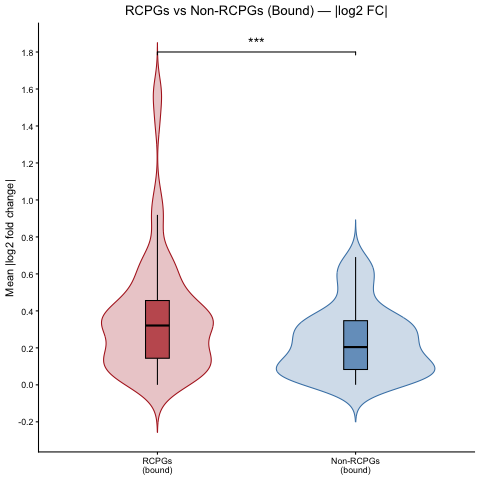

In [ ]:
%%R
## to plot the fold change differences for bound rcpgs vs other bound genes
library(ggplot2)
library(dplyr)
library(tidyr)
library(scales)
library(ggsignif)

output_dir <- "/Users/jacobfine/Library/CloudStorage/OneDrive-Personal/U of T 2022-2023/Blencowe/Jan_2024_Blencowe/NOV_2024_reanalysis/sequence_analysis_may_2026/compare_backgrounds_codon/outputs/figures/figure_3"
cohens_d_df_r = cohens_d_df

# reshape data to long format for plotting
df_plot <- tibble(
  rbp = rownames(cohens_d_df_r),
  rcpgs_bound = abs(cohens_d_df_r$mean_rcpg_bound_fc),
  nonrcpgs_bound = abs(cohens_d_df_r$mean_nonrcpg_bound_fc)
) %>%
  pivot_longer(
    cols = c(rcpgs_bound, nonrcpgs_bound),
    names_to = "group",
    values_to = "fold_change"
  ) %>%
  mutate(
    group = factor(group, levels = c("rcpgs_bound", "nonrcpgs_bound"))
  )

# run t-test
test <- t.test(
  abs(cohens_d_df_r$mean_rcpg_bound_fc),
  abs(cohens_d_df_r$mean_nonrcpg_bound_fc),
  paired = TRUE
)

stars <- case_when(
  test$p.value < 0.001 ~ "***",
  test$p.value < 0.01  ~ "**",
  test$p.value < 0.05  ~ "*",
  TRUE                 ~ "ns"
)

sig_y <- max(df_plot$fold_change, na.rm = TRUE) * 1.08

# make paired violin plot
p <- ggplot(df_plot,
            aes(x = group,
                y = fold_change,
                fill = group,
                color = group)) +
  
  geom_violin(
    alpha = 0.25,
    width = 0.8,
    trim = FALSE
  ) +
  
  geom_boxplot(
    width = 0.12,
    outlier.shape = NA,
    alpha = 0.7,
    color = "black"
  ) +

  
  geom_signif(
    comparisons = list(c("rcpgs_bound", "nonrcpgs_bound")),
    annotations = stars,
    tip_length = 0.01,
    y_position = sig_y,
    textsize = 5,
    color = "black"
  ) +
  
  scale_fill_manual(
    values = c("rcpgs_bound" = "firebrick",
               "nonrcpgs_bound" = "steelblue")
  ) +
  
  scale_color_manual(
    values = c("rcpgs_bound" = "firebrick",
               "nonrcpgs_bound" = "steelblue")
  ) +
  
  scale_x_discrete(
    labels = c("rcpgs_bound" = "RCPGs\n(bound)",
               "nonrcpgs_bound" = "Non-RCPGs\n(bound)")
  ) +
  
  scale_y_continuous(
    breaks = pretty_breaks(n = 10)
  ) +
  
  labs(
    title = "RCPGs vs Non-RCPGs (Bound); absolute log2FC",
    x = NULL,
    y = "Mean |log2 fold change|"
  ) +
  
  theme_classic(base_size = 11) +
  theme(
    legend.position = "none",
    plot.title = element_text(hjust = 0.5)
  )

print(p)

# Print means and test results
cat(sprintf("RCPGs (bound): %.4f\n", mean(abs(cohens_d_df_r$mean_rcpg_bound_fc))))
cat(sprintf("Non-RCPGs (bound): %.4f\n", mean(abs(cohens_d_df_r$mean_nonrcpg_bound_fc))))
cat(sprintf("\nMean difference: %.4f\n", 
            mean(abs(cohens_d_df_r$mean_rcpg_bound_fc)) - mean(abs(cohens_d_df_r$mean_nonrcpg_bound_fc))))
cat("paired t-test\n")
cat(sprintf("t = %.4f, p = %.4e\n", test$statistic, test$p.value))
cat(sprintf("Test result: %s\n", stars))

ggsave(
  filename = file.path(output_dir, "rcpg_vs_nonrcpg_bound_paired_violin_absval.pdf"),
  plot = p,
  width = 4,
  height = 5,
  useDingbats = FALSE)

ggsave(
  filename = file.path(output_dir, "rcpg_vs_nonrcpg_bound_paired_violin_absval.png"),
  plot = p,
  width = 4,
  height = 5,
  dpi = 300)

cat(sprintf("\nPlot saved to: %s\n", output_dir))

In [ ]:
## can lookup binding score
lookup_z_score_rbp = dict(zip(ratio_df_kmer.index,ratio_df_kmer['Z_rare_vs_all']))
cohens_d_df['Z_rare_vs_all']=cohens_d_df['rbp'].map(lookup_z_score_rbp)
df_master['kmer_binding_events_per_nt'] =  round(df_master['kmer_binding_events']/df_master['length_in_nt'],4)
lookup_binding_rcpg_to_rbp = dict(zip(df_master['gene'],df_master['kmer_binding_events_per_nt']))


In [ ]:
#   for each rbp, mean fold change of all rcpgs present in the df

def get_rcpg_fc_by_rbp(df_long, rbp_list, rcpg_set):
    rcpg_set = set(rcpg_set)

    sub = df_long[df_long['rbp'].isin(rbp_list) &
                  df_long['gene'].isin(rcpg_set)].dropna(subset=['log2fc']).copy()
    sub['abs_log2fc'] = sub['log2fc'].abs()

    out = (sub.groupby('rbp')
              .agg(n_rcpg=('log2fc', 'size'),
                   mean_rcpg_fc=('log2fc', 'mean'),
                   mean_rcpg_fc_abs=('abs_log2fc', 'mean'))
              .reset_index())

    return out


## rcpgs only
binding_df = get_rcpg_fc_by_rbp(df_long, common_rbps_clip_shrna, rcegs_set)
binding_df

In [ ]:
## looks up number of rcpgs bound for each rbp
binding_df['a_in_rcegs_and_bound'] = binding_df['rbp'].apply(
        lambda r: len(get_rcpgs_bound_by_rbp(r, lookup_rbp_binding_genes, set(rcegs_common))['rcpgs_bound'])
        if r in lookup_rbp_binding_genes else np.nan
    )

In [ ]:
## to compare the binding to fold change
ratio_df_kmer['rbp'] = ratio_df_kmer.index
df_merge = pd.merge(binding_df.reset_index(), ratio_df_kmer, left_on='rbp', right_on='rbp')

Z=1.96
ratio_df_kmer_top_z1 = ratio_df_kmer[ratio_df_kmer['Z_rare_vs_all'] > Z]  ## update that
top_rbps_z1_full_name_here = list(set(ratio_df_kmer_top_z1.index))
df_merge['is_top_rbp']=df_merge['index'].isin(top_rbps_z1_full_name_here)

In [ ]:
df_merge['rbp_label']=df_merge['rbp'].str.replace('_','-')

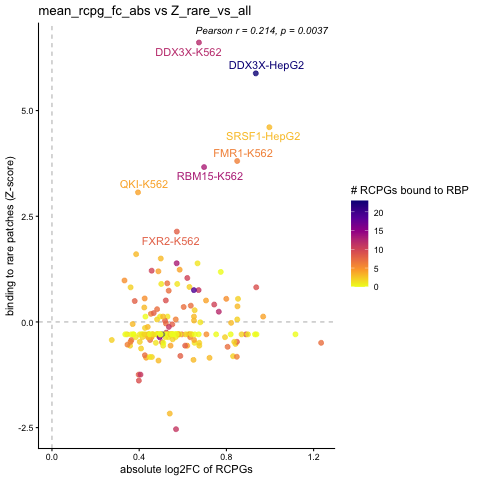

In [ ]:
%%R -i df_merge
## to visualize the correlation between binding and fold change
library(dplyr)
library(ggplot2)
library(ggrepel)
library(viridis)

df <- df_merge

x_col <- 'mean_rcpg_fc_abs'
y_col <- 'Z_rare_vs_all'

# tag top binding rbps
df <- df %>%
  filter(
    is.finite(.data[[x_col]]),
    is.finite(.data[[y_col]])
  ) %>%
  mutate(
    label_rbp = ifelse((.data[[y_col]] > 1.96), as.character(rbp_label), NA)
  )

# correlation
ct <- cor.test(df[[x_col]], df[[y_col]], method = "pearson")
r_lab <- sprintf("Pearson r = %.3f, p = %.2g", ct$estimate, ct$p.value)

p <- ggplot(df, aes_string(x = x_col, y = y_col, color = "a_in_rcegs_and_bound")) +
  geom_hline(yintercept = 0, linetype = "dashed", color = "gray") +
  geom_vline(xintercept = 0, linetype = "dashed", color = "gray") +
  geom_point(alpha = 0.8, size = 2) +
  geom_text_repel(aes(label = label_rbp), na.rm = TRUE, max.overlaps = Inf) +
  annotate("text", x = Inf, y = Inf, label = r_lab,
           hjust = 1.05, vjust = 1.5, size = 3.5, fontface = "italic") +
  scale_color_viridis_c(name = "# RCPGs bound to RBP", option = "C", direction = -1) +
  theme_classic() +
  labs(
    title = paste(x_col, "vs", y_col),
    x = 'absolute log2FC of RCPGs',
    y = 'binding to rare patches (Z-score)'
  )

print(p)

ggsave(
  filename = "outputs/figures/figure_3/rbp_world_fig_v3.pdf",
  plot = p,
  width = 6,
  height = 4
)

# Repeat expansion analysis

In [ ]:
bed_dir = config['outputs']['files']['output_kmers']
bed_dir

{'path': 'outputs/files/output_kmers/',
 'description': 'contains bed and csv files of the kmers'}

In [ ]:
bed_dir

{'path': 'outputs/files/output_kmers/',
 'description': 'contains bed and csv files of the kmers'}

In [ ]:
import os
import pandas as pd
import numpy as np
import pybedtools
from scipy.stats import fisher_exact
%load_ext rpy2.ipython

## intersects sequnece sets with desease tandem repeat expansions

# load k-mer bed files
bed_dir = config['outputs']['files']['output_kmers']['path']
bed_dict = {}
for filename in os.listdir(bed_dir):
    if filename.endswith(".bed"):
        df = pd.read_csv(os.path.join(bed_dir, filename), sep='\t', header=None,
                         names=["chrom", "start", "end", "name", "score", "strand"])
        bed_dict[filename.replace(".bed", "")] = df
print("loaded k-mer sets:", list(bed_dict.keys()))
overlap = 0.01  # min reciprocal overlap fraction
df_tandem = pd.read_csv(config['input_files']['repeats']['disease_loci']['path'])
df_tandem_bed = df_tandem[['chrom', 'start_hg38', 'stop_hg38', 'gene']].copy()
df_tandem_bed.columns = ['chrom', 'start', 'end', 'gene']

# sequence sets
sequence_sets = {
    'rare_patches':  bed_dict['rare_patches'],
    'within_genes':  bed_dict['within_genes'],
    'between_genes': bed_dict['between_genes'],
}

# intersect two bed dataframes, return overlap rows
def intersector_bed(df_bed1, df_bed2, min_overlap=overlap):
    b1 = pybedtools.BedTool.from_dataframe(df_bed1)
    b2 = pybedtools.BedTool.from_dataframe(df_bed2)
    return b1.intersect(b2, wa=False, wb=False, f=min_overlap, r=True, wo=True).to_dataframe()

# standard error of proportion
def proportion_sem(x, n):
    if n == 0:
        return np.nan
    phat = x / n
    return np.sqrt(phat * (1 - phat) / n)

# ffishers test to combpute overlap
def compute_overlap_fisher(fg_df, bg_df, df_to_intersect):
    a = intersector_bed(fg_df, df_to_intersect)['name'].nunique()
    c = intersector_bed(bg_df, df_to_intersect)['name'].nunique()
    fg_total = fg_df['name'].nunique()
    bg_total = bg_df['name'].nunique()
    fg_rate = a / fg_total if fg_total else 0
    bg_rate = c / bg_total if bg_total else 0
    oddsratio, pval = fisher_exact([[a, fg_total - a], [c, bg_total - c]])
    return {'fg_overlap': a, 'fg_total': fg_total, 'fg_rate': fg_rate,
            'bg_overlap': c, 'bg_total': bg_total, 'bg_rate': bg_rate,
            'fold_enrichment': fg_rate / bg_rate if bg_rate else np.inf,
            'odds_ratio': oddsratio, 'fisher_pval': pval}

# run fisher on each sequnece set
results_DIS_tandem = {lab: compute_overlap_fisher(sequence_sets['rare_patches'], sequence_sets[lab], df_tandem_bed)
                      for lab in ('within_genes', 'between_genes')}

print("\noverlap of each k-mer set with disease repeats")
for lab, r in results_DIS_tandem.items():
    print(f"rare vs {lab}: or = {r['odds_ratio']:.2f}, fisher p = {r['fisher_pval']:.3g}")

results_DIS_tandem_DF = pd.DataFrame(results_DIS_tandem).T

# proportion + sem per set, for plotting
summary_df = pd.DataFrame([
    {'label': lab,
     'x': intersector_bed(df, df_tandem_bed)['name'].nunique(),
     'n': df['name'].nunique()}
    for lab, df in sequence_sets.items()
])
summary_df['phat'] = summary_df['x'] / summary_df['n']
summary_df['sem'] = [proportion_sem(x, n) for x, n in zip(summary_df['x'], summary_df['n'])]
print(summary_df)

loaded k-mer sets: ['within_genes', 'between_genes', 'rare_patches']

overlap of each k-mer set with disease repeats
rare vs within_genes: or = 3.80, fisher p = 0.0409
rare vs between_genes: or = 10.06, fisher p = 0.000209
           label  x     n      phat       sem
0   rare_patches  9   458  0.019651  0.006486
1   within_genes  3   571  0.005254  0.003025
2  between_genes  3  1508  0.001989  0.001147


`height` was translated to `width`.
`height` was translated to `width`.



Attaching package: ‘dplyr’

The following objects are masked from ‘package:stats’:

    filter, lag

The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union

In addition: Warning messages:
1: package ‘ggplot2’ was built under R version 4.5.3 
2: package ‘dplyr’ was built under R version 4.5.3 
3: `geom_errorbarh()` was deprecated in ggplot2 4.0.0.
ℹ Please use the `orientation` argument of `geom_errorbar()` instead.
This warning is displayed once per session.
Call `lifecycle::last_lifecycle_warnings()` to see where this warning was
generated. 


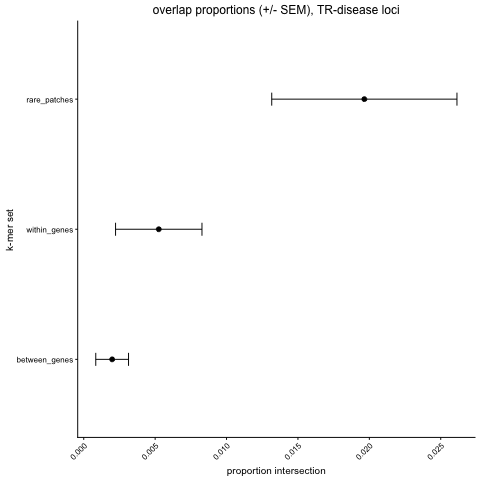

In [ ]:
%%R -i summary_df
library(ggplot2)
library(dplyr)

# plot overlap of each sequnece set with disease repeats
 
summary_df <- summary_df %>%
  mutate(label = factor(label, levels = label[order(phat)]))

# plots with SEM (of proportion) error bars
p <- ggplot(summary_df, aes(x = phat, y = label)) +
  geom_point(color = "black", size = 2) +
  geom_errorbarh(
    aes(xmin = phat - sem, xmax = phat + sem),
    height = 0.10, color = "black"
  ) +
  scale_x_continuous(breaks = seq(0, 1, by = 0.005)) +  # NEW: tick every 0.05 instead of 0.2
  labs(
    x = expression("proportion intersection"),
    y = "k-mer set",
    title = "overlap proportions (+/- SEM), TR-disease loci"
  ) +
  theme_classic(base_size = 10) +
  theme(
    axis.text.y = element_text(margin = margin(r = 2)),
    plot.title = element_text(face = "plain", hjust = 0.5),
    axis.title.y = element_text(vjust = 0.5),
    axis.title.x = element_text(vjust = -0.2),
    axis.text.x = element_text(angle = 45, hjust = 1)  # Angle labels if crowded
  )

ggsave(
  filename = 'outputs/figures/figure_4/proportion_overlap_sem_v3.pdf',
  plot = p,
  width = 6,
  height = 6
)
print(p)

In [ ]:

# makes design matrix for rare patches and their overlap with other tandom repeats

# other TRs to intersect with
# custom TR analysis of repeats from: https://zenodo.org/records/13987414
df_all_TRs = pd.read_csv(config['input_files']['repeats']['tr_regions']['path'], delimiter='\t', header=None)

# makes it into bed format
df_all_TRs = df_all_TRs[[0, 1, 2]].copy()
df_all_TRs.columns = ['chrom', 'start', 'end']
df_all_TRs['gene'] = 'blank'

# also makes df copy of disease TRs
df_disease_TRs = df_tandem_bed.copy()

import pybedtools
import pandas as pd

## reads teh bed files
bed_dir = config['outputs']['files']['output_kmers']['path']


dfs_bed_for_intersection = bed_dict.copy()

# loads bed files to consider

df_bed_rare = dfs_bed_for_intersection['rare_patches']

# sets up background control kmer sets
df_controls_within = dfs_bed_for_intersection['within_genes']
df_controls_between = dfs_bed_for_intersection['between_genes']

# makes dict of them all for convenience
dfs_bed_for_intersection_combined = {
    'within_genes': df_controls_within,
    'between_genes': df_controls_between,
    'rare_patches': df_bed_rare
}




bed_rare = pybedtools.BedTool.from_dataframe(dfs_bed_for_intersection_combined['rare_patches'])
bed_within = pybedtools.BedTool.from_dataframe(dfs_bed_for_intersection_combined['within_genes'])
bed_between = pybedtools.BedTool.from_dataframe(dfs_bed_for_intersection_combined['between_genes'])

bed_all_TRs = pybedtools.BedTool.from_dataframe(df_all_TRs)
bed_disease_TRs = pybedtools.BedTool.from_dataframe(df_disease_TRs)

# makes it into a dict for convenience
bed_dict = {
    'rare_patches': bed_rare,
    'within_genes': bed_within,
    'between_genes': bed_between
}

# counts the number of overlaps for each genomic coordinate in k-mer set
def count_overlaps_min_fraction(query_bed, target_bed, min_fraction=0.01):
    intersection = query_bed.intersect(target_bed, c=True, f=min_fraction).to_dataframe(
        names=['chrom', 'start', 'end', 'gene', 'n']
    )
    return intersection

# makes a design matrix to perform regression
design_matrices = {}

for label, query_bed in bed_dict.items():
    # applies to get number of overlapping info for each k-mer
    df_all_overlap = count_overlaps_min_fraction(query_bed, bed_all_TRs, min_fraction=0.01)
    df_all_overlap = df_all_overlap.rename(columns={'n': 'n_overlap_all_TRs'})
    
    df_disease_overlap = count_overlaps_min_fraction(query_bed, bed_disease_TRs, min_fraction=0.01)
    df_disease_overlap = df_disease_overlap.rename(columns={'n': 'n_overlap_disease_TRs'})
    
    # makes the design matrices
    df_design = df_all_overlap.drop(columns=['gene']).copy()
    df_design['gene'] = df_all_overlap['gene']
    df_design['n_overlap_disease_TRs'] = df_disease_overlap['n_overlap_disease_TRs']
    df_design['group'] = label
    
    design_matrices[label] = df_design

# joins them together into one matrix
df_design_matrix = pd.concat(design_matrices.values(), ignore_index=True)
df_design_matrix['is_rare'] = (df_design_matrix['group'] == 'rare_patches').astype(int)
df_design_matrix['is_within'] = (df_design_matrix['group'] == 'within_genes').astype(int)
df_design_matrix['is_between'] = (df_design_matrix['group'] == 'between_genes').astype(int)

# creates binary outcomes
df_design_matrix['overlaps_disease_TR'] = (df_design_matrix['n_overlap_disease_TRs'] > 0).astype(int)
df_design_matrix['overlaps_any_TR'] = (df_design_matrix['n_overlap_all_TRs'] > 0).astype(int)
# reoders and clean columns
df_design_matrix = df_design_matrix[['chrom', 'start', 'end', 'gene',
                                     'is_rare', 'is_within', 'is_between',
                                     'n_overlap_all_TRs', 'n_overlap_disease_TRs',
                                     'overlaps_any_TR', 'overlaps_disease_TR']]

print(df_design_matrix.head())
print(f"\nGroup distribution:")
print(f"  Rare: {df_design_matrix['is_rare'].sum()}")
print(f"  Within genes: {df_design_matrix['is_within'].sum()}")
print(f"  Between genes: {df_design_matrix['is_between'].sum()}")

%R -i df_design_matrix


      chrom                      start  end gene  is_rare  is_within  \
0  28355876  ENSG00000004142_(117_168)    9    -        1          0   
1  25013715  ENSG00000004848_(279_366)   15    -        1          0   
2  27184649  ENSG00000005073_(495_576)   13    -        1          0   
3   7294479    ENSG00000006047_(21_93)   12    -        1          0   
4  97006166  ENSG00000006377_(111_189)   12    +        1          0   

   is_between  n_overlap_all_TRs  n_overlap_disease_TRs  overlaps_any_TR  \
0           0                  0                      0                0   
1           0                  1                      1                1   
2           0                  1                      0                1   
3           0                  0                      0                0   
4           0                  1                      0                1   

   overlaps_disease_TR  
0                    0  
1                    1  
2                    0  
3         

In [ ]:
%%R

## stratified conditional logistic regression to 'regress out' overlap with other TRs

library(survival)


model_clogit <- clogit(
  overlaps_disease_TR ~ is_rare + strata(overlaps_any_TR),
  data = df_design_matrix,
  method = "exact"
)

print(summary(model_clogit))

# get results
OR <- exp(coef(model_clogit)["is_rare"])
ci <- confint(model_clogit)
ci_is_rare <- exp(ci[which(rownames(ci) == "is_rare"), ])
p_value <- summary(model_clogit)$coefficients["is_rare", "Pr(>|z|)"]

cat("summary of results\n")
cat("\nodds ratio for is_rare:", round(OR, 3), "\n")
cat("95% CI:", round(ci_is_rare[1], 3), "-", round(ci_is_rare[2], 3), "\n")
cat("P-value:", round(p_value, 4), "\n")

Call:
coxph(formula = Surv(rep(1, 2561L), overlaps_disease_TR) ~ is_rare + 
    strata(overlaps_any_TR), data = df_design_matrix, method = "exact")

  n= 2561, number of events= 16 

         coef exp(coef) se(coef)     z Pr(>|z|)   
is_rare 1.516     4.554    0.520 2.915  0.00355 **
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

        exp(coef) exp(-coef) lower .95 upper .95
is_rare     4.554     0.2196     1.643     12.62

Concordance= 0.679  (se = 0.061 )
Likelihood ratio test= 8.79  on 1 df,   p=0.003
Wald test            = 8.5  on 1 df,   p=0.004
Score (logrank) test = 10.18  on 1 df,   p=0.001

summary of results

odds ratio for is_rare: 4.554 
95% CI: 1.643 - 12.618 
P-value: 0.0036 


In addition: Warning message:
package ‘survival’ was built under R version 4.5.2 


# RNA structure

In [ ]:
import gzip 
import pandas as pd


## obtain genomic sequence to analyze sturcture 

genome_file = config['input_files']['seq_process']['genome']['path'] 
from Bio import SeqIO 
import gzip

with gzip.open(genome_file, "rt") as handle:
    genome_fasta = SeqIO.parse(handle, "fasta") 
    genome_dict = SeqIO.to_dict(genome_fasta)  
chrom = 'chr1'
start = 959215
end = 959246

seq = genome_dict[chrom].seq[start-1:end]  
seq

Seq('CTCTTGCGGCTCCCCGCAGCTGCCATGACACC')

In [ ]:
## apply it to a df to extract sequneces
def extract_sequences_from_df(row):

    
    chrom = row['chrom']  
    start = row['start'] 
    end = row['end']  
    strand = row['strand']
    
    if chrom in genome_dict:  
        seq = genome_dict[chrom].seq[start-1:end] 

        
        if strand == "-": 
            seq = seq.reverse_complement()

        seq = ''.join(seq) 
    return seq

all_kmer_info['meta_kmer'] = all_kmer_info.apply(extract_sequences_from_df, axis=1)


In [ ]:
import RNA

## get folding energy for an RNA
def get_mfe(seq):
    structure, mfe = RNA.fold(seq)
    return mfe

all_kmer_info['mfe'] = all_kmer_info['meta_kmer'].apply(get_mfe)


In [ ]:
from scipy.stats import ttest_ind
from statsmodels.stats.multitest import multipletests
import pandas as pd
import numpy as np

# separate groups
rare_mfe = all_kmer_info[all_kmer_info['kmer_set'] == 'rare_patches']['mfe']
between_mfe = all_kmer_info[all_kmer_info['kmer_set'] == 'between_genes']['mfe']
within_mfe = all_kmer_info[all_kmer_info['kmer_set'] == 'within_genes']['mfe']

# comparisons to make for RNA structure
comparisons = [
    ('rare_patches vs between_genes', rare_mfe, between_mfe),
    ('rare_patches vs within_genes', rare_mfe, within_mfe)
]

# store results
pvals = []
tstats = []
percent_diffs = []
fold_changes = []
cohens_d_list = []
mean_rare_list = []
mean_control_list = []
mean_diffs = []
std_diffs = []

# perform independent t-tests
for comparison_name, group1, group2 in comparisons:
    t_stat, p_val = ttest_ind(group1, group2)
    tstats.append(t_stat)
    pvals.append(p_val)
    mean_g1 = group1.mean()
    mean_g2 = group2.mean()
    mean_rare_list.append(mean_g1)
    mean_control_list.append(mean_g2)
    
    mean_diff = mean_g1 - mean_g2
    mean_diffs.append(mean_diff)
    
    # calculate fold change (rare / control)
    fold_change = mean_g1 / mean_g2 if mean_g2 != 0 else np.nan
    fold_changes.append(fold_change)
    # percent differnece
    pct_diff = ((mean_g1 - mean_g2) / abs(mean_g2)) * 100 if mean_g2 != 0 else np.nan
    percent_diffs.append(pct_diff)
    
    # calculate Cohen's d for independent samples
    # d = (mean1 - mean2) / pooled_std
    n1, n2 = len(group1), len(group2)
    var1, var2 = group1.var(ddof=1), group2.var(ddof=1)
    pooled_std = np.sqrt(((n1-1)*var1 + (n2-1)*var2) / (n1 + n2 - 2))
    cohens_d = mean_diff / pooled_std
    cohens_d_list.append(cohens_d)
    std_diffs.append(pooled_std)

# apply BH correction
rej, pvals_corrected, _, _ = multipletests(pvals, alpha=0.05, method='fdr_bh')

# make results dataframe
results_df = pd.DataFrame({
    'comparison': [c[0] for c in comparisons],
    'mean_rare_patches': mean_rare_list,
    'mean_control': mean_control_list,
    'mean_difference': mean_diffs,
    'pooled_std': std_diffs,
    'fold_change': fold_changes,
    't_stat': tstats,
    'cohens_d': cohens_d_list,
    'percent_difference': percent_diffs,
    'raw_pval': pvals,
    'bh_corrected_pval': pvals_corrected,
    'significant': rej
})
results_df


,comparison,mean_rare_patches,mean_control,mean_difference,pooled_std,fold_change,t_stat,cohens_d,percent_difference,raw_pval,bh_corrected_pval,significant
0,rare_patches vs between_genes,-25.025311,-21.848408,-3.176903,10.211045,1.145407,-5.946089,-0.311124,-14.540660,3.235903e-09,3.235903e-09,True
1,rare_patches vs within_genes,-25.025311,-17.994396,-7.030915,10.723998,1.390728,-10.599430,-0.655624,-39.072806,5.207805e-25,1.041561e-24,True


In [ ]:
all_kmer_info

,name,host_gene,kmer_set,chrom,start,end,strand,meta_kmer,mfe,kmer_category,length,mfe_per_nt
0,ENSG00000004848__s0__from__ENSG00000128610_(13...,ENSG00000004848,within_genes,chrX,25013203,25013256,-,GACGAGGAGGAGCTGCTGGAGGACGACGCCCGCGCGCTGCTCAAGG...,-17.299999,within_genes,53,-0.326415
1,ENSG00000004848__s1__from__ENSG00000173366_(33...,ENSG00000004848,within_genes,chrX,25013176,25013235,-,GACGACGCCCGCGCGCTGCTCAAGGAGCCCCGGCGCTGTCCTGTGG...,-22.100000,within_genes,59,-0.374576
2,ENSG00000008735__s2__from__ENSG00000103241_(78...,ENSG00000008735,within_genes,chr22,50604662,50604718,+,CGCGCCGCCCGCCCGGGACGAGCCTGCTCCGCCGCCTGCTCCGAGG...,-20.700001,within_genes,56,-0.369643
3,ENSG00000008735__s3__from__ENSG00000048392_(84...,ENSG00000008735,within_genes,chr22,50603999,50604046,+,AGCCGCTCGAGCGGCGGCCGCGGGGGACGTCGCAGCAGCCAGGAGCTG,-19.200001,within_genes,47,-0.408511
4,ENSG00000038219__s4__from__ENSG00000198763_(27...,ENSG00000038219,within_genes,chr4,13601866,13601916,-,AAATGTGATGGTTCTTTAAGTAGAGACTCAGAAATAGTTGAAGGAA...,-9.600000,within_genes,50,-0.192000
...,...,...,...,...,...,...,...,...,...,...,...,...
2556,ENSG00000240445_(102_156)_p2---rare_patches,ENSG00000240445,rare_patches,chr17,18680741,18680764,-,CTGCGCCTCACGGCCAGATCCCAG,-7.300000,rare_patches,23,-0.317391
2557,ENSG00000260001_(540_612)_p2---rare_patches,ENSG00000260001,rare_patches,chr19,7917473,7917487,+,TGTCTGCCTCAGGAC,-2.200000,rare_patches,14,-0.157143
2558,ENSG00000282872_(261_339)_p2---rare_patches,ENSG00000282872,rare_patches,chr1,26165826,26165830,-,GACCA,0.000000,rare_patches,4,0.000000
2559,ENSG00000288000_(162_243)_p2---rare_patches,ENSG00000288000,rare_patches,chr20,43459771,43459777,+,GTGGTGG,0.000000,rare_patches,6,0.000000


In [ ]:
label_map = {
    'rare_patches':  'rare_patches',
    'between_genes': 'between_genes',
    'within_genes':  'within_genes',
}
all_kmer_info['kmer_category'] = all_kmer_info['kmer_set'].map(label_map)

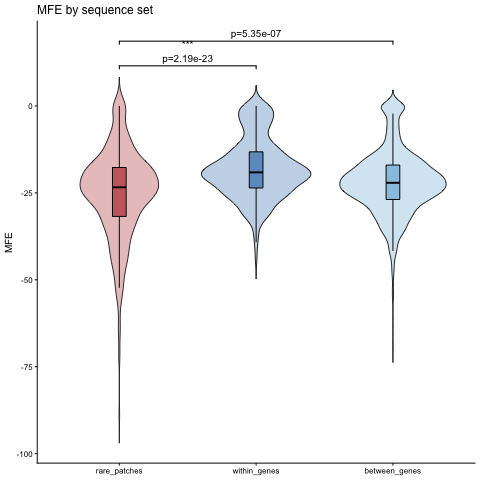

In [ ]:
%%R -i all_kmer_info
## plots the mfe of different kmer sets

library(ggplot2)
library(dplyr)
library(tidyr)
library(ggsignif)

df_plot <- all_kmer_info %>%
  filter(kmer_category %in% c("rare_patches", "within_genes", "between_genes")) %>%
  drop_na(mfe) %>%
  mutate(kmer_category = factor(kmer_category,
                                levels = c("rare_patches", "within_genes", "between_genes")))

# ttest on mfe between groups
tt <- function(g1, g2) {
  x <- df_plot$mfe[df_plot$kmer_category == g1]
  y <- df_plot$mfe[df_plot$kmer_category == g2]
  t.test(x, y)$p.value
}

p1 <- tt("rare_patches", "within_genes")
p2 <- tt("rare_patches", "between_genes")

stars <- function(p) ifelse(p < 0.001, "***", ifelse(p < 0.01, "**", ifelse(p < 0.05, "*", "ns")))

y_max <- max(df_plot$mfe, na.rm = TRUE)
y_rng <- diff(range(df_plot$mfe, na.rm = TRUE))

p <- ggplot(df_plot, aes(x = kmer_category, y = mfe, fill = kmer_category)) +
  geom_violin(alpha = 0.3, width = 0.8, trim = FALSE) +
  geom_boxplot(width = 0.10, outlier.shape = NA, alpha = 0.6, color = "black") +
  geom_signif(comparisons = list(c("rare_patches", "within_genes")),
              annotations = paste0(stars(p1), "\np=", signif(p1, 3)),
              y_position = y_max + 0.08 * y_rng, tip_length = 0.01, textsize = 3.5, color = "black") +
  geom_signif(comparisons = list(c("rare_patches", "between_genes")),
              annotations = paste0(stars(p2), "\np=", signif(p2, 3)),
              y_position = y_max + 0.16 * y_rng, tip_length = 0.01, textsize = 3.5, color = "black") +
  scale_fill_manual(values = c("rare_patches" = "firebrick",
                               "within_genes" = "#2171b5",
                               "between_genes" = "#6baed6")) +
  labs(x = NULL, y = "MFE", title = "MFE by sequence set") +
  theme_classic(base_size = 10) +
  theme(legend.position = "none")

print(p)

ggsave("outputs/figures/figure_s2/mfe_plot_v2.pdf", p, width = 6, height = 6)